In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from scipy import signal
import math
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from sklearn.metrics import r2_score
from scipy.signal import find_peaks
from scipy.stats import skew

# characteristics of the dataset

In [4]:
data = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/user.csv', sep =',', encoding = 'latin1')
print(data.shape)
data.head()

(467, 3)


,user_id,gender,grade
0,219,1,4
1,220,1,4
2,280,0,3
3,430,1,5
4,291,1,3


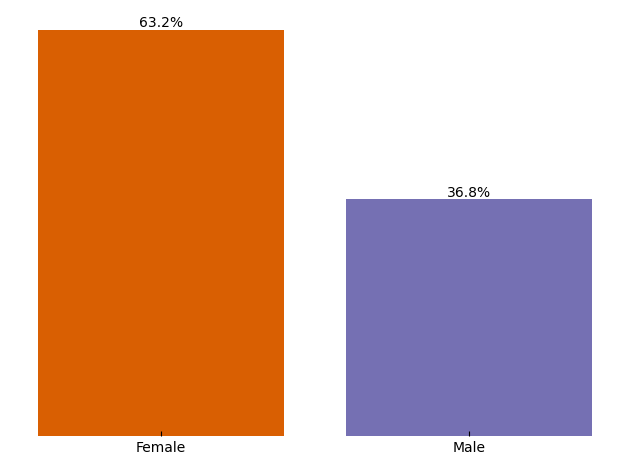

In [5]:
gender_map = {0: 'Male', 1: 'Female'}
data['gender_label'] = data['gender'].map(gender_map)
cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]
count = data['gender_label'].value_counts().sort_values(ascending=False)
total = count.sum()

fig, ax = plt.subplots()
bars = ax.bar(count.index, count.values, color=colors)
ax.set_ylabel('Count')
ax.yaxis.set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
#plt.savefig('figs/gender.png')

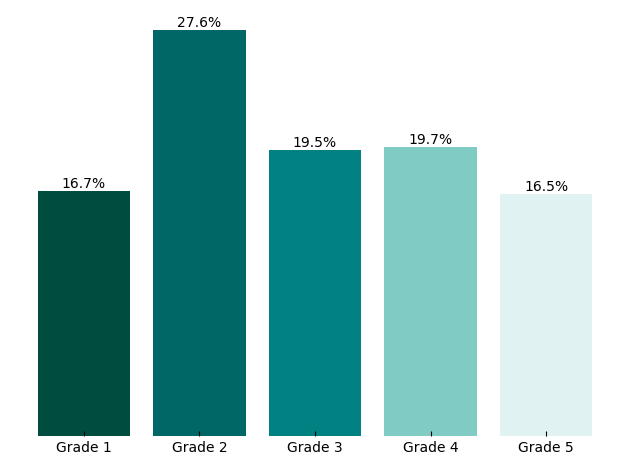

In [6]:
import matplotlib.colors as mcolors
grade_map = {1: 'Grade 1', 2: 'Grade 2', 3: 'Grade 3', 4: 'Grade 4', 5: 'Grade 5'}
data['grade_label'] = data['grade'].map(grade_map)

teal_colors = ["#004d40", "#006666", "#008080", "#80cbc4", "#e0f2f2"]
teal_cmap = mcolors.LinearSegmentedColormap.from_list("teal_dark_light", teal_colors)

count = data['grade_label'].value_counts().sort_index()
total = count.sum()
colors = [teal_cmap(i) for i in np.linspace(0, 1, len(count))]

fig, ax = plt.subplots()
bars = ax.bar(count.index, count.values, color=colors)

ax.set_ylabel('Count')
ax.yaxis.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
#plt.savefig('figs/grade.png')
plt.show()

In [7]:
checkins = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/checkIns.csv', sep =',', encoding = 'latin1')
print(checkins.shape)
checkins.head()
checkins.columns.tolist()

(20397, 9)


['user_id',
 'day',
 'day_of_week',
 'time',
 'latitude',
 'longitude',
 'POI_id',
 'POI_category',
 'mood']

In [8]:
checkins.columns.tolist()
checkinsbyid = checkins['user_id'].value_counts()
print(checkinsbyid)

user_id
99     92
408    92
307    85
120    83
324    78
       ..
211    26
443    25
389    25
407    25
62     25
Name: count, Length: 467, dtype: int64


In [9]:
checkins = checkins.merge(data[['user_id', 'gender']], on='user_id', how='left')
checkins.columns.tolist()
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['mov_day'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date

C:\Users\34633\AppData\Local\Temp\ipykernel_21704\3778694713.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['time'] = pd.to_datetime(checkins['time'])


# DEFINITON OF ENTROPY FUNCTIONS

In [10]:
def shannon_entropy(probs):
    return -np.sum(probs * np.log2(probs))

#UNCORRELATED ENTROPY
def compute_hu(seq):
    if len(seq) == 0: return 0
    probs = pd.Series(seq).value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

#CORRELATED ENTROPY
def find_shortest_new_sequence(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if sequence[j:j + length] == sub_sequence:
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    
    total_lambda = 0
    for i in range(n):
        total_lambda += find_shortest_new_sequence(sequence, i)
        
    return (n * np.log2(n)) / total_lambda

def binary_entropy(x):
    if x <= 0 or x >= 1:
        return 0
    return -x * np.log2(x) - (1 - x) * np.log2(1 - x)

def fano_inequality_root(pi, h, s):
    return h - (binary_entropy(pi) + (1 - pi) * np.log2(s - 1))

def calculate_predictability(h, s):
    if s <= 1 or h <= 0:
        return 1.0
    h_max = np.log2(s)
    if h >= h_max:
        return 1.0 / s
    lower_bound = 1.0 / s
    upper_bound = 0.999999
    try:
        sol = root_scalar(fano_inequality_root, args=(h, s), 
                         bracket=[lower_bound, upper_bound], method='brentq')
        return sol.root
    except (ValueError, RuntimeError):
        return lower_bound

# UNCORRELATED ENTROPY (shannon)

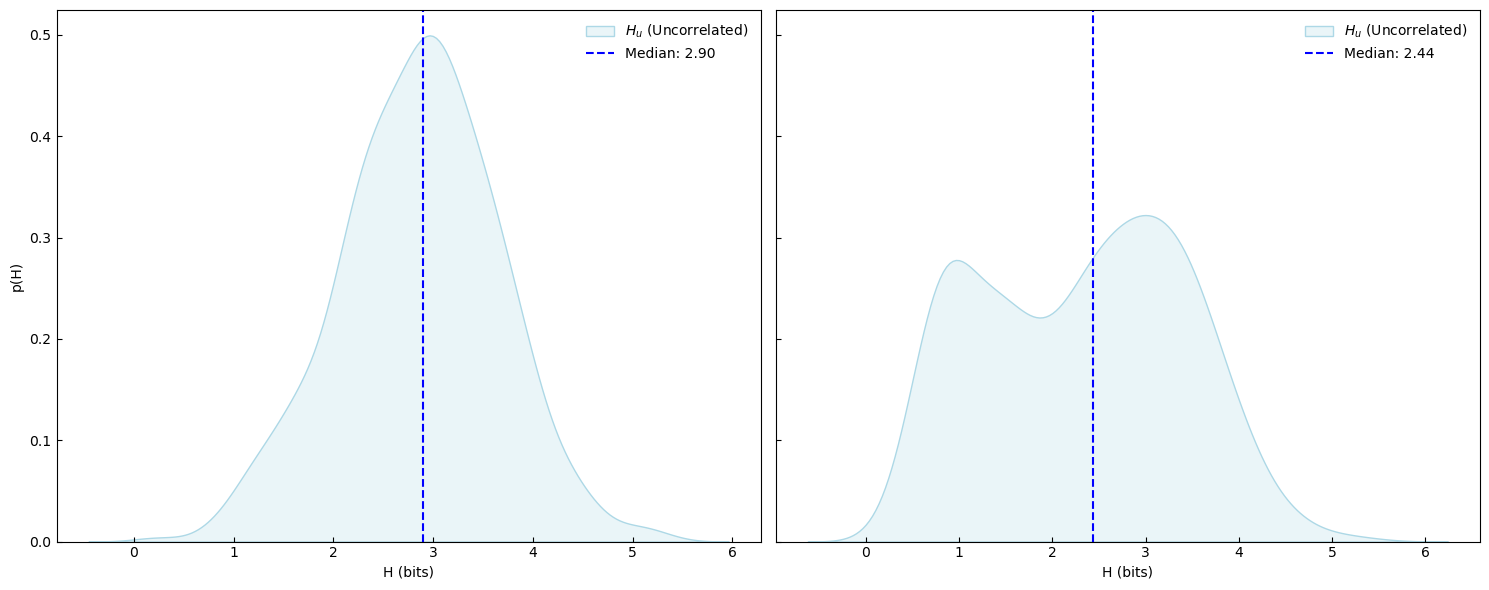

len per user: 467
len per user and day: 729
real users: 467


In [23]:
#ENTROPY CALCULATED WITHOUT DAY ADJUSTMENT
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
user_sequences = checkins.groupby('user_id')['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(len) > 1]
hu_values_BAD = user_sequences.apply(compute_hu)

#ADJUSTED DAY TO INCLUDE EARLY MORNING HOURS
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
user_sequences = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(lambda x: len(set(x)) > 1)]
hu_values = user_sequences.apply(compute_hu)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.kdeplot(hu_values_BAD, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', ax=ax1)
ax1.axvline(hu_values_BAD.median(), linestyle='--', color='blue', label=f'Median: {hu_values_BAD.median():.2f}')
ax1.set_xlabel('H (bits)')
ax1.set_ylabel('p(H)')
ax1.legend(frameon=False)
ax1.tick_params(axis='both', direction='in')

sns.kdeplot(hu_values, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', ax=ax2)
ax2.axvline(hu_values.median(), linestyle='--', color='blue', label=f'Median: {hu_values.median():.2f}')
ax2.set_xlabel('H (bits)')
ax2.set_ylabel('p(H)')
ax2.legend(frameon=False)
ax2.tick_params(axis='both', direction='in')

plt.tight_layout()
plt.show()

print(f"len per user: {len(hu_values_BAD)}")
print(f"len per user and day: {len(hu_values)}")
print(f"real users: {len(hu_values.index.get_level_values('user_id').unique())}")

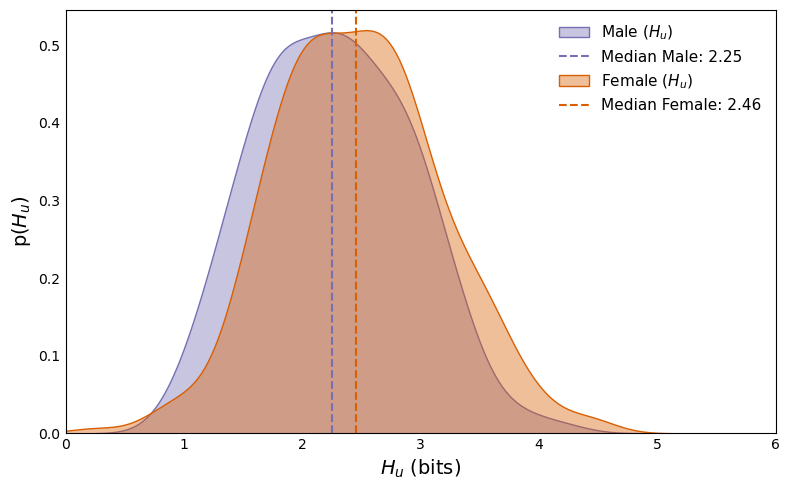

-0.20762942086709968


In [25]:
daily_entropy = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_entropy = daily_entropy[daily_entropy['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_entropy['Hu_val'] = daily_entropy['POI_id'].apply(compute_hu)
user_entropy_final = daily_entropy.groupby(['user_id', 'gender'])['Hu_val'].mean().reset_index()
hu_male = user_entropy_final[user_entropy_final['gender'] == 0]['Hu_val']
hu_female = user_entropy_final[user_entropy_final['gender'] == 1]['Hu_val']

cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]

plt.figure(figsize=(8,5))
sns.kdeplot(hu_male, fill=True, color=colors[1], label='Male ($H_u$)', alpha=0.4)
plt.axvline(hu_male.median(), color=colors[1], linestyle='--',  label=f'Median Male: {hu_male.median():.2f}')
sns.kdeplot(hu_female, fill=True, color=colors[0], label='Female ($H_u$)', alpha=0.4)
plt.axvline(hu_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hu_female.median():.2f}')
plt.xlabel('$H_u$ (bits)', fontsize=14)
plt.ylabel('p($H_u$)', fontsize=14)
plt.legend(frameon=False, fontsize=11)
plt.tick_params(axis='both', direction='in', length=0)
plt.xlim(0, 6)
plt.tight_layout()
#plt.savefig('figs/unc.png')
plt.show()

print(hu_male.median()-hu_female.median())

# CORRELATED ENTROPY

as it says in the paper, the most info we use, the less entropy our system will have because it will be more defined. expect to get lower values of correlated entropy that for uncorrelated

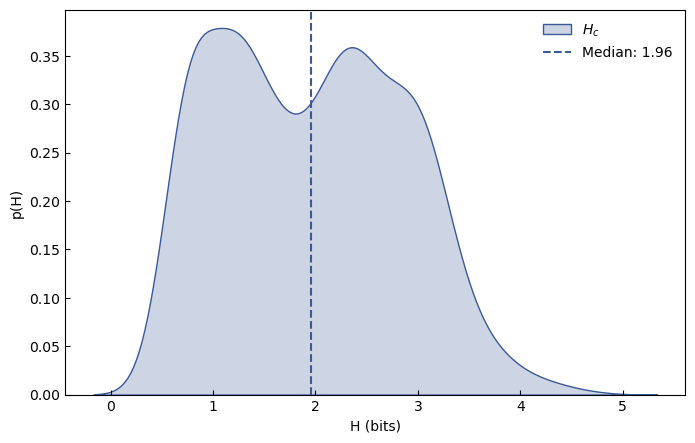

In [26]:
checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
results_hc = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).apply(compute_hc).dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(results_hc, fill=True, color='#3b5998', label='$H_c$')
plt.axvline(results_hc.median(), color='#3b5998', linestyle='--', label=f'Median: {results_hc.median():.2f}')
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.show()

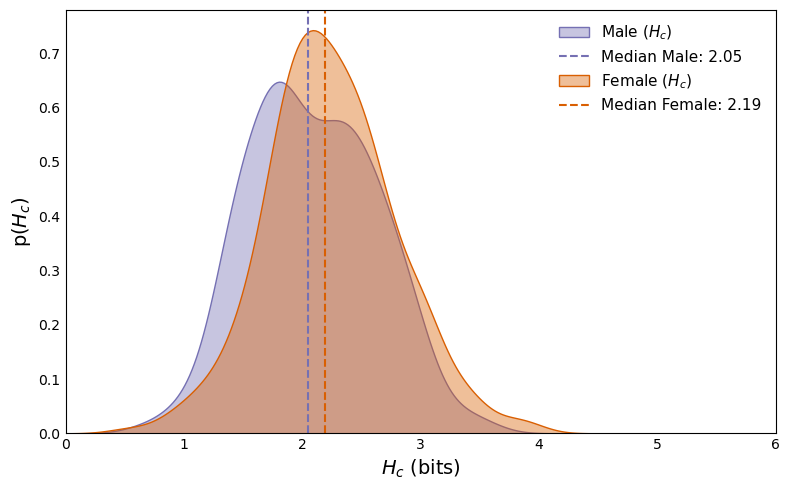

0.1452232917105456


In [27]:
daily_hc = checkins.groupby(['user_id', 'mov_day', 'gender'])['POI_id'].apply(list).reset_index()
daily_hc = daily_hc[daily_hc['POI_id'].apply(lambda x: len(set(x)) > 1)]
daily_hc['Hc_val'] = daily_hc['POI_id'].apply(compute_hc)
user_hc_final = daily_hc.groupby(['user_id', 'gender'])['Hc_val'].mean().reset_index()

hc_male = user_hc_final[user_hc_final['gender'] == 0]['Hc_val']
hc_female = user_hc_final[user_hc_final['gender'] == 1]['Hc_val']

cmap = plt.get_cmap('Dark2')
selected_indices = [1,2]
colors = [cmap(i) for i in selected_indices]

plt.figure(figsize=(8, 5))
sns.kdeplot(hc_male, fill=True, color=colors[1], label='Male ($H_c$)', alpha=0.4)
plt.axvline(hc_male.median(), color=colors[1], linestyle='--', label=f'Median Male: {hc_male.median():.2f}')
sns.kdeplot(hc_female, fill=True, color=colors[0], label='Female ($H_c$)', alpha=0.4)
plt.axvline(hc_female.median(), color=colors[0], linestyle='--', label=f'Median Female: {hc_female.median():.2f}')
plt.xlabel('$H_c$ (bits)', fontsize=14)
plt.ylabel('p($H_c$)', fontsize = 14)
plt.legend(frameon=False, fontsize=11)
plt.tick_params(axis='both', direction='in', length=0)
plt.xlim(0, 6) 
plt.tight_layout()
#plt.savefig('figs/corr.png')
plt.show()

print(hc_female.median()-hc_male.median())

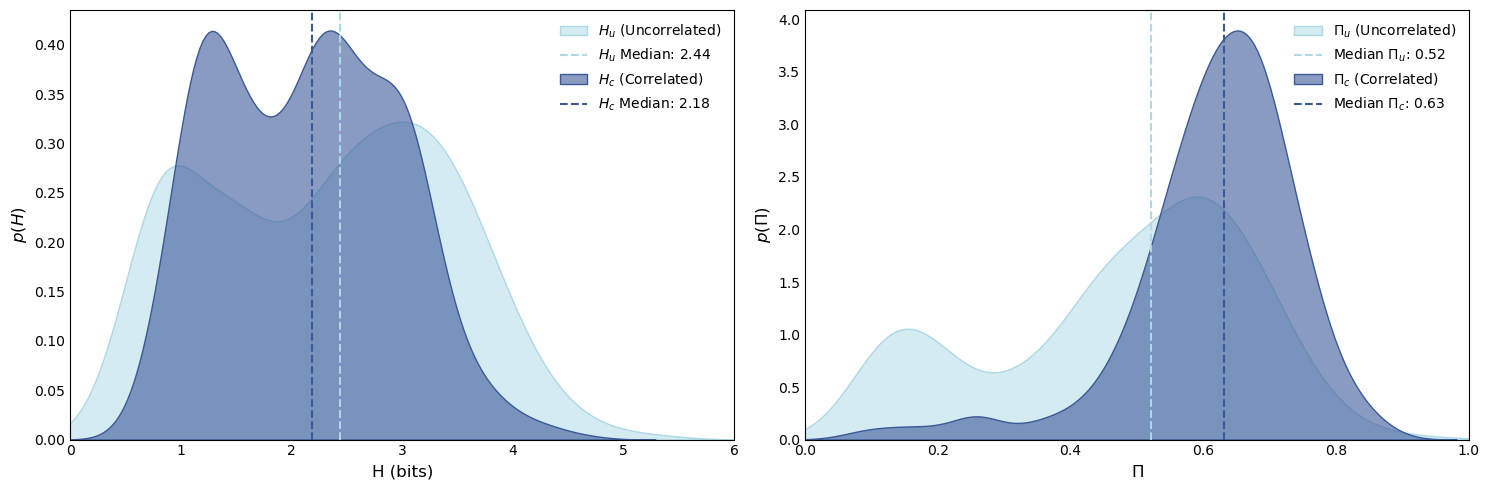

In [28]:
entropy_comparison = pd.DataFrame({'Hu': hu_values,'Hc': results_hc}).dropna()

daily_S = checkins.groupby(['user_id', 'mov_day'])['POI_id'].nunique().reset_index()
avg_S_per_user = daily_S.groupby('user_id')['POI_id'].mean()

def to_clean_series(data):
    if isinstance(data, pd.DataFrame):
        return data.iloc[:, 0]
    return data

hu_series = to_clean_series(hu_values)
hc_series = to_clean_series(results_hc)
if isinstance(hu_series.index, pd.MultiIndex):
    hu_series = hu_series.groupby(level='user_id').mean()
if isinstance(hc_series.index, pd.MultiIndex):
    hc_series = hc_series.groupby(level='user_id').mean()

predict_input = pd.DataFrame({'Hu': hu_series,'Hc': hc_series,'S_avg': avg_S_per_user}).dropna()
predictability_results = []
for uid, row in predict_input.iterrows():
    s = row['S_avg']
    if s > 1:
        pi_u = calculate_predictability(row['Hu'], s)
        pi_c = calculate_predictability(row['Hc'], s)
        predictability_results.append({'user_id': uid, 'Pi_u': pi_u,  'Pi_c': pi_c})

predictability_df = pd.DataFrame(predictability_results)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6)
plt.axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
plt.xlabel('H (bits)', fontsize=12)
plt.ylabel('$p(H)$', fontsize=12)
plt.xlim(0, 6) 
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', length=0)

plt.subplot(1, 2, 2)
sns.kdeplot(predictability_df['Pi_u'], fill=True, color='lightblue', label='$\Pi_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(predictability_df['Pi_u'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"Median $\Pi_u$: {predictability_df['Pi_u'].median():.2f}")
sns.kdeplot(predictability_df['Pi_c'], fill=True, color='#3b5998', label='$\Pi_c$ (Correlated)', alpha=0.6)
plt.axvline(predictability_df['Pi_c'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"Median $\Pi_c$: {predictability_df['Pi_c'].median():.2f}")
plt.xlabel('$\Pi$', fontsize=12)
plt.ylabel('$p(\Pi)$', fontsize=12)
plt.xlim(0, 1)
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', length=0)

plt.tight_layout()
#plt.savefig('figs/comp.png', bbox_inches='tight', dpi=300)

trajectory shuffle...


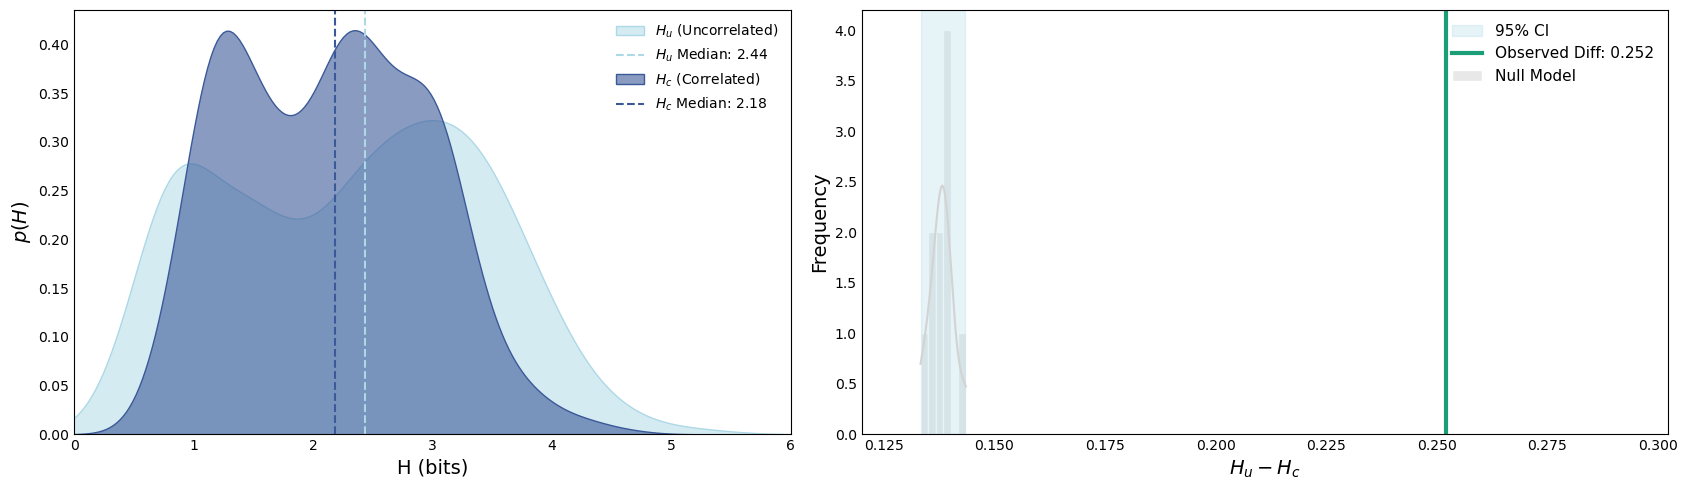


--- null model ---
95% ci: [0.13340, 0.14340]
real diff: 0.2521
p-value: 0.000000


In [ ]:
entropy_comparison = pd.DataFrame({'Hu': hu_values, 'Hc': results_hc}).dropna()
obs_diff_global = 0.2521388561149407
null_diffs_trajectory = []
n_permutations = 1000

print("trajectory shuffle...")

for i in range(n_permutations):
    shuffled_checkins = checkins.copy()
    shuffled_checkins['POI_id'] = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].transform(np.random.permutation)
    
    daily_entropy_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_entropy_null = daily_entropy_null[daily_entropy_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_entropy_null['Hu_val'] = daily_entropy_null['POI_id'].apply(compute_hu)
    user_hu_null = daily_entropy_null.groupby('user_id')['Hu_val'].mean()
    
    daily_hc_null = shuffled_checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list).reset_index()
    daily_hc_null = daily_hc_null[daily_hc_null['POI_id'].apply(lambda x: len(set(x)) > 1)]
    daily_hc_null['Hc_val'] = daily_hc_null['POI_id'].apply(compute_hc)
    user_hc_null = daily_hc_null.groupby('user_id')['Hc_val'].mean()
    
    null_diff = (user_hu_null - user_hc_null).mean()
    null_diffs_trajectory.append(null_diff)

null_diffs_trajectory = np.array(null_diffs_trajectory)

ci_low_traj = np.percentile(null_diffs_trajectory, 0.5)
ci_high_traj = np.percentile(null_diffs_trajectory, 99.5)
p_val_trajectory = np.mean(null_diffs_trajectory >= obs_diff_global)

fig, axs = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [8, 9]})
cmap = plt.get_cmap('Dark2')

sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
axs[0].set_xlabel('H (bits)', fontsize=14)
axs[0].set_ylabel('$p(H)$', fontsize=14)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=10)
axs[0].tick_params(axis='both', length=0)

sns.histplot(null_diffs_trajectory, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1])
axs[1].axvspan(ci_low_traj, ci_high_traj, color='lightblue', alpha=0.3, label='95% CI')
axs[1].axvline(obs_diff_global, color=cmap(0), lw=3, linestyle='-', label=f'Observed Diff: {obs_diff_global:.3f}')
axs[1].axvline(0, color='black', lw=1, linestyle='--')
y_max = axs[1].get_ylim()[1]
x_range = max(abs(null_diffs_trajectory.min()), abs(null_diffs_trajectory.max()), abs(obs_diff_global)) * 1.2
axs[1].set_xlim(0.12, obs_diff_global+0.05)
axs[1].set_ylim(0, y_max)
axs[1].set_xlabel(r'$ H_u - H_c $', fontsize=14)
axs[1].set_ylabel('Frequency', fontsize=14)
axs[1].tick_params(axis='both', length=0)
axs[1].legend(frameon=False, fontsize=11, loc='upper right')

plt.tight_layout()
#plt.savefig('figs/entropy_and_shuffling_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n--- null model ---")
print(f"95% ci: [{ci_low_traj:.5f}, {ci_high_traj:.5f}]")
print(f"real diff: {obs_diff_global:.4f}")
print(f"p-value: {p_val_trajectory:.6f}")

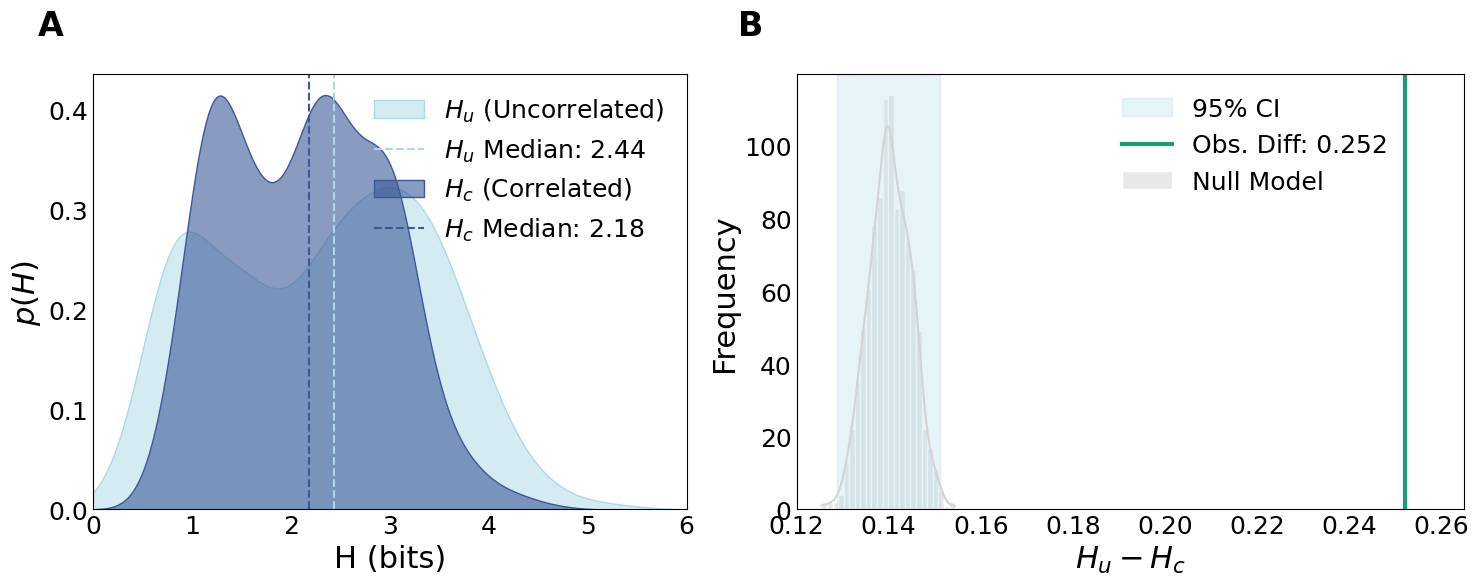


--- RESULTADOS DEL MODELO NULO ---
95% Confidence Interval: [0.12874, 0.15126]
Diferencia Observada Real: 0.2521
p-value: 0.000000


In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [8, 9]})
cmap = plt.get_cmap('Dark2')

axs[0].text(-0.05, 1.15, 'A', transform=axs[0].transAxes, fontsize=24, fontweight='bold', va='top', ha='right')
sns.kdeplot(entropy_comparison['Hu'], fill=True, color='lightblue', label='$H_u$ (Uncorrelated)', alpha=0.5, ax=axs[0])
axs[0].axvline(entropy_comparison['Hu'].median(), color='lightblue', linestyle='--', linewidth=1.5, label=f"$H_u$ Median: {entropy_comparison['Hu'].median():.2f}")
sns.kdeplot(entropy_comparison['Hc'], fill=True, color='#3b5998', label='$H_c$ (Correlated)', alpha=0.6, ax=axs[0])
axs[0].axvline(entropy_comparison['Hc'].median(), color='#3b5998', linestyle='--', linewidth=1.5, label=f"$H_c$ Median: {entropy_comparison['Hc'].median():.2f}")
axs[0].set_xlabel('H (bits)', fontsize=22)
axs[0].set_ylabel('$p(H)$', fontsize=22)
axs[0].set_xlim(0, 6) 
axs[0].legend(frameon=False, fontsize=18, loc='upper right')
axs[0].tick_params(axis='both', length=0, labelsize=18)

axs[1].text(-0.05, 1.15, 'B', transform=axs[1].transAxes, fontsize=24, fontweight='bold', va='top', ha='right')
sns.histplot(null_diffs_trajectory, kde=True, color='lightgray', edgecolor='white', label='Null Model', ax=axs[1])
axs[1].axvspan(ci_low_traj, ci_high_traj, color='lightblue', alpha=0.3, label='95% CI')
axs[1].axvline(obs_diff_global, color=cmap(0), lw=3, linestyle='-', label=f'Obs. Diff: {obs_diff_global:.3f}')
axs[1].axvline(0, color='black', lw=1, linestyle='--')
y_max = axs[1].get_ylim()[1]
x_range = max(abs(null_diffs_trajectory.min()), abs(null_diffs_trajectory.max()), abs(obs_diff_global)) * 1.2
axs[1].set_xlim(0.12, 0.265)
axs[1].set_ylim(0, y_max)
axs[1].set_xlabel(r'$ H_u - H_c $', fontsize=22)
axs[1].set_ylabel('Frequency', fontsize=22)
axs[1].tick_params(axis='both', length=0, labelsize=18)
# bbox_to_anchor=(x, y) -> bajar la x de 1.0 a 0.85 la mueve a la izquierda
axs[1].legend(frameon=False, fontsize=18, loc='upper right', bbox_to_anchor=(0.92, 1.0))

plt.tight_layout()
plt.savefig('entropy_and_shuffling_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n--- RESULTADOS DEL MODELO NULO ---")
print(f"95% Confidence Interval: [{ci_low_traj:.5f}, {ci_high_traj:.5f}]")
print(f"Diferencia Observada Real: {obs_diff_global:.4f}")
print(f"p-value: {p_val_trajectory:.6f}")

bien!!!!! per la correlated hi ha mes densitat de probabilitat a entropies menors

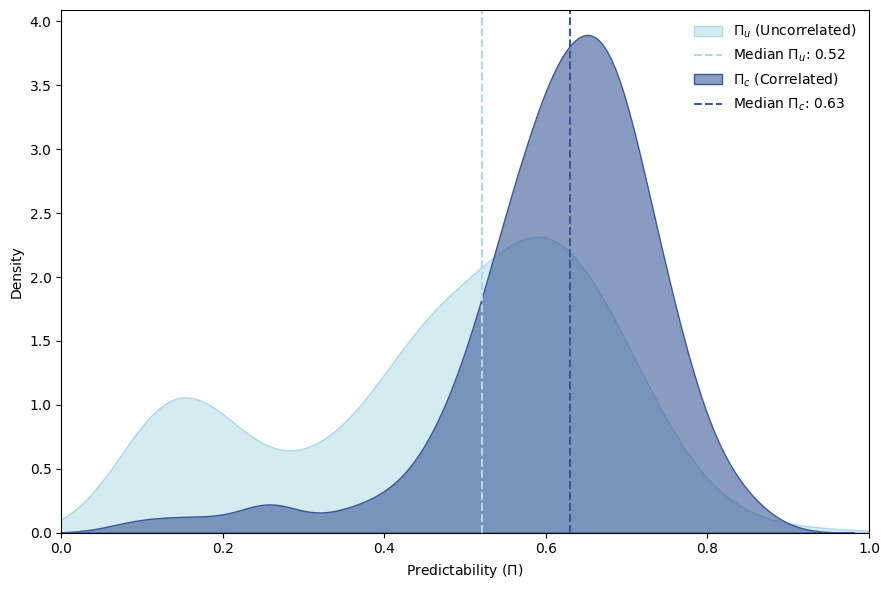

In [ ]:
daily_S = checkins.groupby(['user_id', 'mov_day'])['POI_id'].nunique().reset_index()
avg_S_per_user = daily_S.groupby('user_id')['POI_id'].mean()

def to_clean_series(data):
    if isinstance(data, pd.DataFrame):
        return data.iloc[:, 0]
    return data

hu_series = to_clean_series(hu_values)
hc_series = to_clean_series(results_hc)
if isinstance(hu_series.index, pd.MultiIndex):
    hu_series = hu_series.groupby(level='user_id').mean()
if isinstance(hc_series.index, pd.MultiIndex):
    hc_series = hc_series.groupby(level='user_id').mean()

predict_input = pd.DataFrame({'Hu': hu_series,'Hc': hc_series,'S_avg': avg_S_per_user}).dropna()
predictability_results = []
for uid, row in predict_input.iterrows():
    s = row['S_avg']
    if s > 1:
        pi_u = calculate_predictability(row['Hu'], s)
        pi_c = calculate_predictability(row['Hc'], s)
        predictability_results.append({'user_id': uid, 'Pi_u': pi_u,  'Pi_c': pi_c})

predictability_df = pd.DataFrame(predictability_results)

plt.figure(figsize=(9, 6))
sns.kdeplot(predictability_df['Pi_u'], fill=True, color='lightblue', label='$\Pi_u$ (Uncorrelated)', alpha=0.5)
plt.axvline(predictability_df['Pi_u'].median(), color='lightblue', linestyle='--', label=f'Median $\Pi_u$: {predictability_df["Pi_u"].median():.2f}')

sns.kdeplot(predictability_df['Pi_c'], fill=True, color='#3b5998', label='$\Pi_c$ (Correlated)', alpha=0.6)
plt.axvline(predictability_df['Pi_c'].median(), color='#3b5998', linestyle='--', label=f'Median $\Pi_c$: {predictability_df["Pi_c"].median():.2f}')

per la correlated la predictabilitat es major!! tops

## window of observation

no tiene sentido!! si un usuario solo visita una localizacion en una hora la predictabilidad no tiene sentido. vamos a hacer lo mismo excluyendo usuarios que no se mueven en el time slot o ampliando la ventana de observacion

# CATEGORIES OF POIS

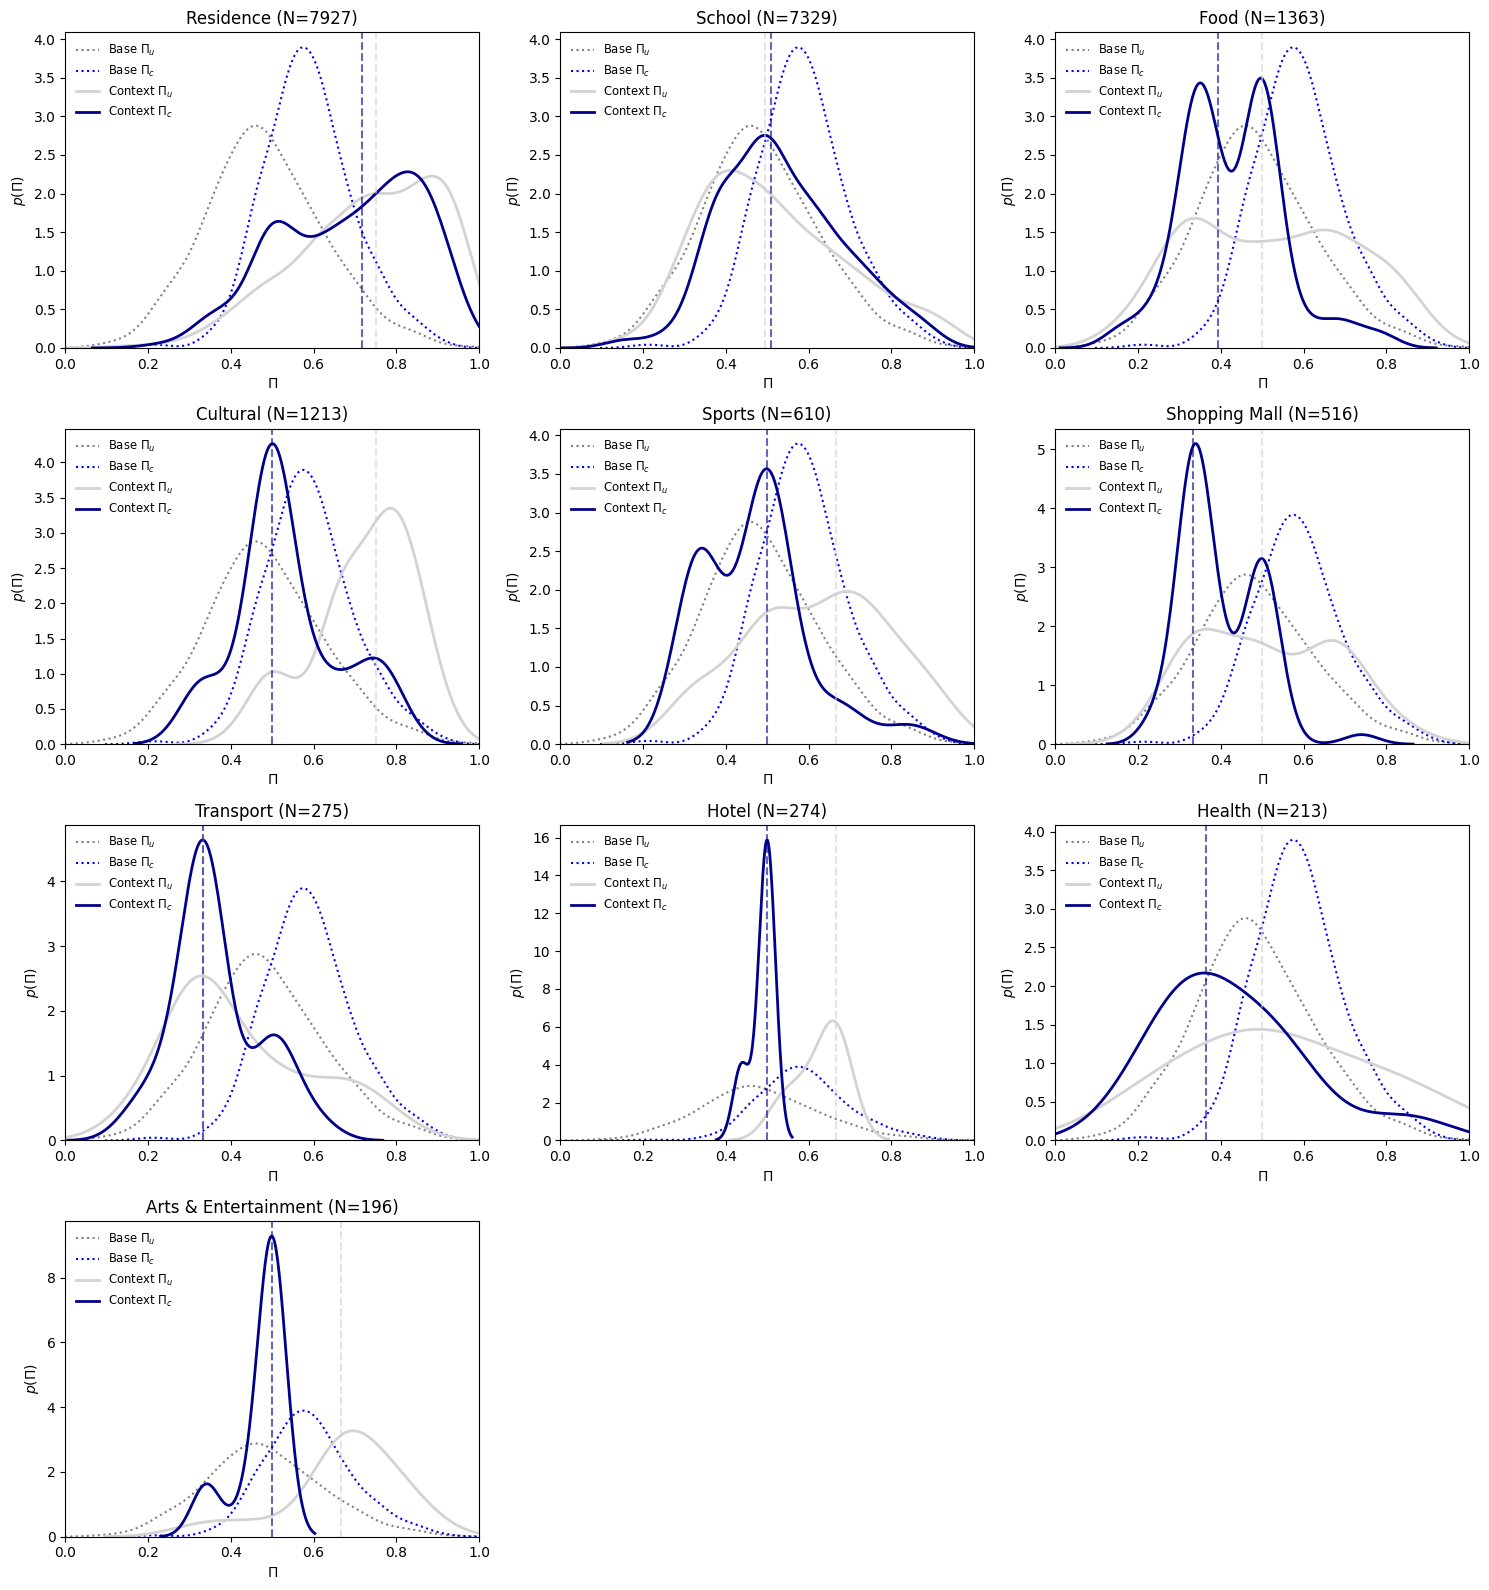

In [ ]:
def plot_refined_mobility_grid(df, min_checkins=150):
    baseline_list = []
    for _, group in df.groupby('user_id'):
        seq = group['POI_id'].tolist()
        s = len(set(seq))
        if s > 1:
            hu = compute_hu(seq)
            hc = compute_hc(seq)
            baseline_list.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s) })
    df_baseline = pd.DataFrame(baseline_list)
    cat_counts = df['POI_category'].value_counts()
    valid_categories = cat_counts[cat_counts >= min_checkins].index.tolist()
    n_cats = len(valid_categories)
    cols = 3
    rows = math.ceil(n_cats / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()
    for i, cat in enumerate(valid_categories):
        cat_results = []
        cat_df = df[df['POI_category'] == cat]
        for _, user_data in cat_df.groupby('user_id'):
            seq = user_data['POI_id'].tolist()
            s = len(set(seq))
            if s > 1 and len(seq) >= 3:
                hu = compute_hu(seq)
                hc = compute_hc(seq)
                cat_results.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s)})
        df_cat = pd.DataFrame(cat_results)
        ax = axes[i]
        sns.kdeplot(df_baseline['pi_u'], color='gray', ls=':', ax=ax, label='Base $\Pi_u$')
        sns.kdeplot(df_baseline['pi_c'], color='blue', ls=':', ax=ax, label='Base $\Pi_c$')
        if len(df_cat) > 1 and df_cat['pi_c'].nunique() > 1:
            sns.kdeplot(df_cat['pi_u'], color='lightgray', lw=2, ax=ax, label=f'Context $\Pi_u$')
            sns.kdeplot(df_cat['pi_c'], color='darkblue', lw=2, ax=ax, label=f'Context $\Pi_c$')
            ax.axvline(df_cat['pi_u'].median(), color='lightgray', ls='--', alpha=0.6)
            ax.axvline(df_cat['pi_c'].median(), color='darkblue', ls='--', alpha=0.6)
        else:
            ax.text(0.5, 0.5, 'not enough data', 
                    ha='center', va='center', transform=ax.transAxes, color='red')
        ax.set_title(f"{cat} (N={cat_counts[cat]})")
        ax.set_xlim(0, 1)
        ax.set_xlabel("$\Pi$")
        ax.set_ylabel("$p(\Pi)$")
        ax.legend(loc='upper left', fontsize='small', frameon=False)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
plot_refined_mobility_grid(checkins, min_checkins=150)

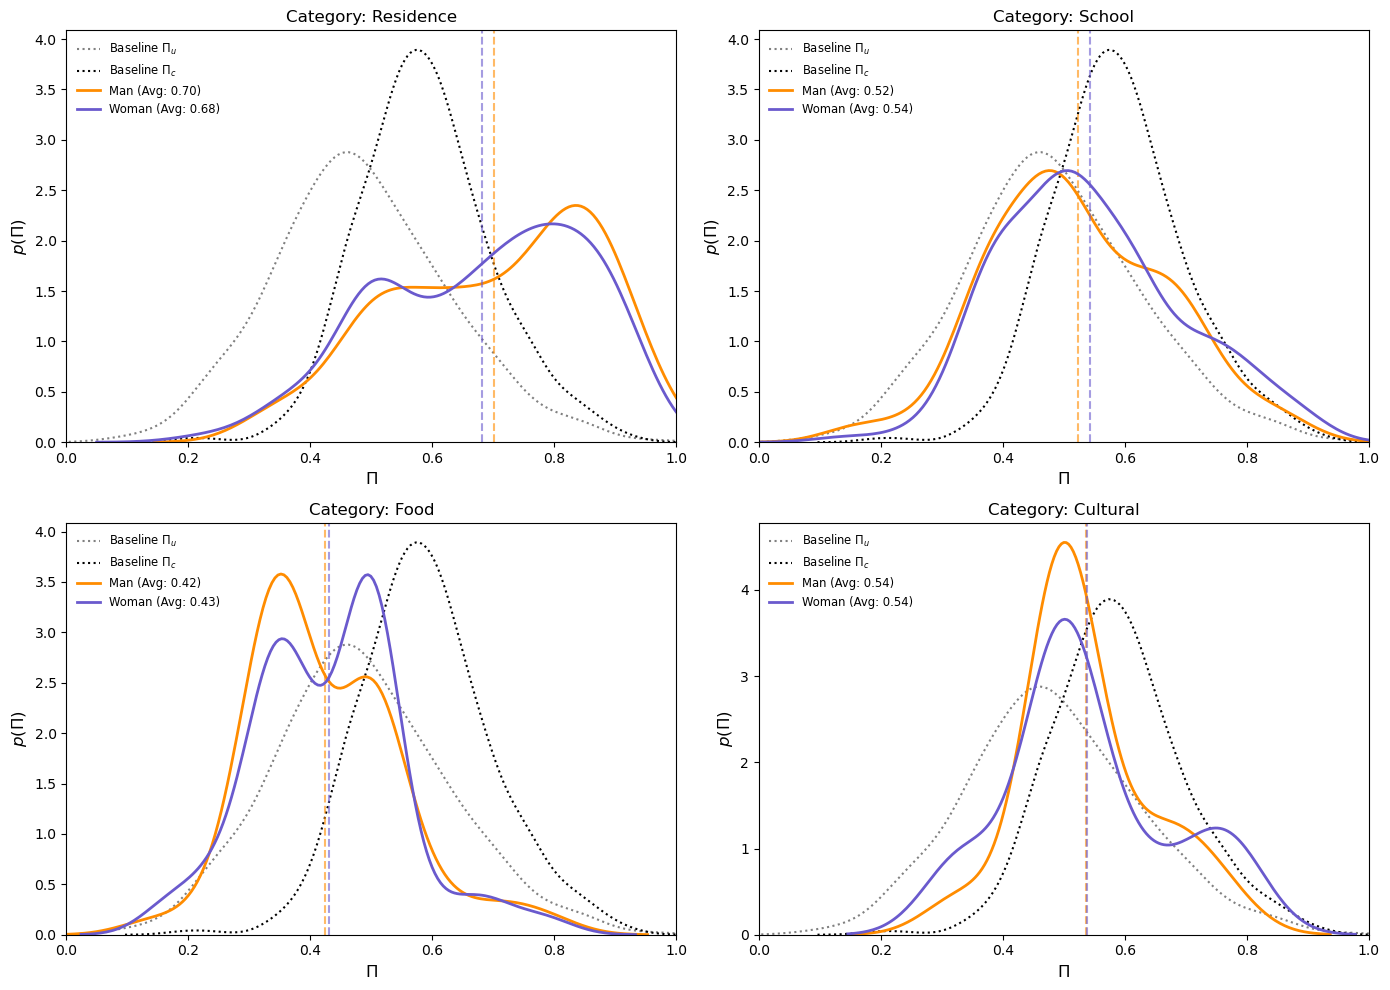

    Category Gender  Mean_Pi_c  Skewness_Pi_c  Count
0  Residence    Man   0.700233      -0.404116    126
1  Residence  Woman   0.680947      -0.389913    210
2     School    Man   0.522735       0.144277    155
3     School  Woman   0.543210       0.360464    284
4       Food    Man   0.423676       0.740450     55
5       Food  Woman   0.430608       0.321809    104
6   Cultural    Man   0.535730       0.549751     15
7   Cultural  Woman   0.538421       0.426313     43


In [38]:
def plot_gender_comparison_with_stats(df, target_categories=['Residence', 'School', 'Food', 'Cultural']):
    stats_list = [] 
    baseline_list = []
    for _, group in df.groupby('user_id'):
        seq = group['POI_id'].tolist()
        s = len(set(seq))
        if s > 1:
            hu = compute_hu(seq)
            hc = compute_hc(seq)
            baseline_list.append({'pi_u': calculate_predictability(hu, s),'pi_c': calculate_predictability(hc, s)})
    df_baseline = pd.DataFrame(baseline_list)
    n_cats = len(target_categories)
    cols = 2
    rows = math.ceil(n_cats / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
    axes = axes.flatten()
    
    gender_map = {0: {'label': 'Man', 'color': 'darkorange'}, 1: {'label': 'Woman', 'color': 'slateblue'}}

    for i, cat in enumerate(target_categories):
        cat_df = df[df['POI_category'] == cat]
        ax = axes[i]
        sns.kdeplot(df_baseline['pi_u'], color='gray', ls=':', ax=ax, label='Baseline $\Pi_u$')
        sns.kdeplot(df_baseline['pi_c'], color='black', ls=':', ax=ax, label='Baseline $\Pi_c$')

        for gender_val in [0, 1]:
            gender_data = cat_df[cat_df['gender'] == gender_val]
            gender_results = []
            for _, user_data in gender_data.groupby('user_id'):
                seq = user_data['POI_id'].tolist()
                s = len(set(seq))
                if s > 1 and len(seq) >= 3:
                    hu = compute_hu(seq)
                    hc = compute_hc(seq)
                    gender_results.append({'pi_c': calculate_predictability(hc, s) })
            
            df_gender = pd.DataFrame(gender_results)
            if not df_gender.empty and df_gender['pi_c'].nunique() > 1:
                config = gender_map[gender_val]
                m_val = df_gender['pi_c'].mean()
                s_val = skew(df_gender['pi_c'].dropna())
                stats_list.append({'Category': cat,'Gender': config['label'],'Mean_Pi_c': m_val,'Skewness_Pi_c': s_val,'Count': len(df_gender)})
                sns.kdeplot(df_gender['pi_c'], lw=2, ax=ax, label=f"{config['label']} (Avg: {m_val:.2f})", color=config['color'])
                ax.axvline(m_val, ls='--', alpha=0.6, color=config['color'])
                ax.set_xlabel("$\Pi$", fontsize=12)
                ax.set_ylabel("$p(\Pi)$", fontsize=12)

        ax.set_title(f"Category: {cat}")
        ax.set_xlim(0, 1)
        ax.legend(loc='upper left', fontsize='small', frameon=False)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(stats_list)
df_resumen_stats = plot_gender_comparison_with_stats(checkins)
print(df_resumen_stats)

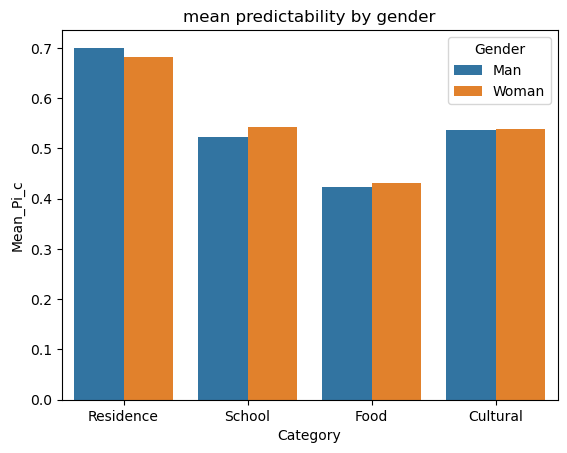

In [41]:
sns.barplot(data=df_resumen_stats, x='Category', y='Mean_Pi_c', hue='Gender')
plt.title("mean predictability by gender")
plt.show()

WAVELET TRANSFROM. aixo es per veure quin dels cicles te mes importancia en la predictabilitat

C:\Users\34633\AppData\Local\Temp\ipykernel_5864\3473675790.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins_filt['time'] = pd.to_datetime(checkins_filt['time'])


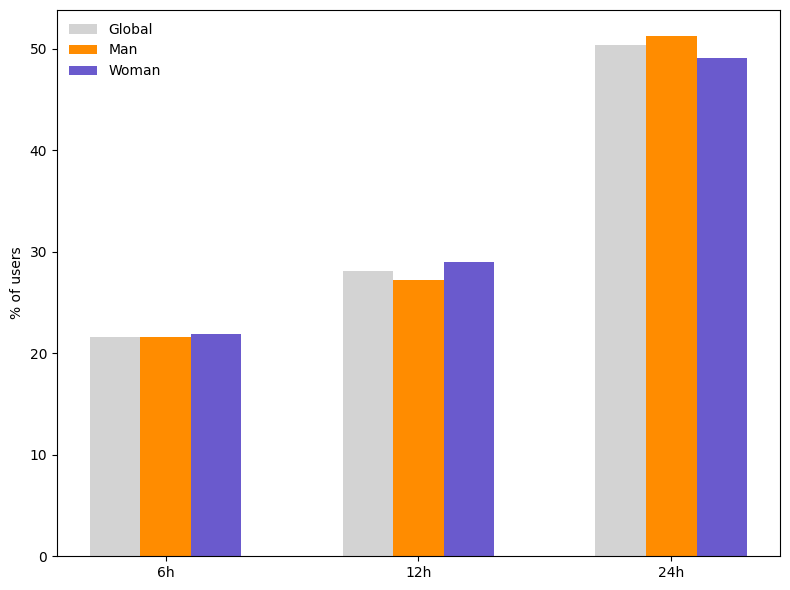

In [95]:
S_total = checkins.groupby('user_id')['POI_id'].nunique()
usuarios_activos = S_total[S_total >= 5].index
checkins_filt = checkins[checkins['user_id'].isin(usuarios_activos)].copy()

checkins_filt['time'] = pd.to_datetime(checkins_filt['time'])
checkins_filt['hour'] = checkins_filt['time'].dt.hour
checkins_filt['timeslot'] = (checkins_filt['day_of_week'] - 1) * 24 + checkins_filt['hour']

periodic_results = []
for (slot, uid), group in checkins_filt.groupby(['timeslot', 'user_id']):
    if len(group) < 2: continue
    h_u_t = compute_hu(group['POI_id'].tolist())
    s_val = S_total[uid]
    if s_val > 1:
        pi_val = calculate_predictability(h_u_t, s_val)
        gender_val = group['gender'].iloc[0]
        periodic_results.append({'timeslot': slot, 'user_id': uid, 'pi': pi_val, 'gender': gender_val})
df_pi_t = pd.DataFrame(periodic_results)

def analyze_frequencies(df_input):
    if df_input.empty: return None, None, None
    pi_matrix = df_input.pivot(index='user_id', columns='timeslot', values='pi')
    pi_matrix = pi_matrix.apply(lambda row: row.fillna(row.mean()), axis=1).dropna()
    if pi_matrix.empty: return None, None, None
    avg_signal = pi_matrix.mean(axis=0).values
    n = len(avg_signal)
    yf = fft(avg_signal - np.mean(avg_signal))
    xf = fftfreq(n, 1) 
    periods = 1 / xf[1:n//2] 
    power = np.abs(yf[1:n//2])**2
    user_modes = []
    for uid in pi_matrix.index:
        u_sig = pi_matrix.loc[uid].values
        u_yf = fft(u_sig - np.mean(u_sig))
        u_pow = np.abs(u_yf[1:n//2])**2
        idx24 = np.argmin(np.abs(periods - 24))
        idx12 = np.argmin(np.abs(periods - 12))
        idx6 = np.argmin(np.abs(periods - 6))
        pvals = {'24h': u_pow[idx24], '12h': u_pow[idx12], '6h': u_pow[idx6]}
        user_modes.append(max(pvals, key=pvals.get))
    return periods, power, user_modes

p_all, pow_all, m_all = analyze_frequencies(df_pi_t)
p_man, pow_man, m_man = analyze_frequencies(df_pi_t[df_pi_t['gender'] == 0])
p_woman, pow_woman, m_woman = analyze_frequencies(df_pi_t[df_pi_t['gender'] == 1])

def get_dist(modes):
    if not modes: return [0, 0, 0]
    s = pd.Series(modes).value_counts(normalize=True) * 100
    return [s.get('6h', 0), s.get('12h', 0), s.get('24h', 0)]

fig, ax = plt.subplots(figsize=(8, 6))
labels = ['6h', '12h', '24h']
x = np.arange(len(labels))

ax.bar(x - 0.2, get_dist(m_all), 0.2, label='Global', color='lightgray')
ax.bar(x, get_dist(m_man), 0.2, label='Man', color='darkorange')
ax.bar(x + 0.2, get_dist(m_woman), 0.2, label='Woman', color='slateblue')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% of users')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## DISTRIBUTION OF LOGINS

C:\Users\34633\AppData\Local\Temp\ipykernel_21704\1084390757.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  login['hour'] = pd.to_datetime(login['time'], errors='coerce').dt.hour


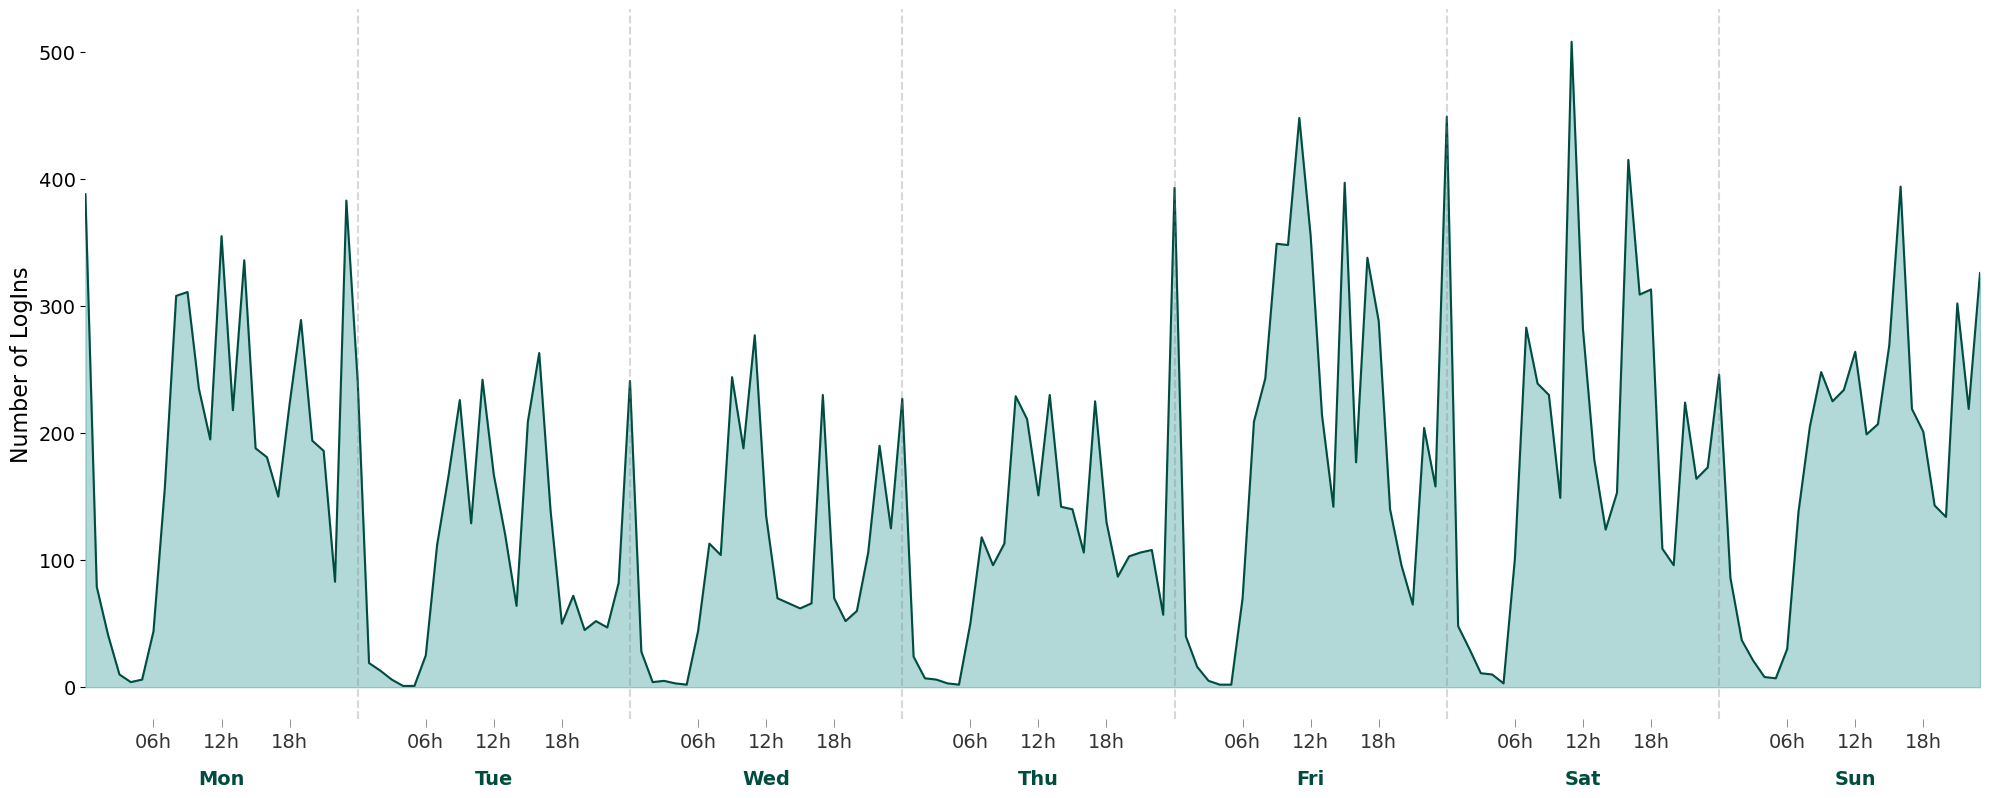

In [45]:
column_names = ['user_id', 'day', 'day_of_week', 'time']
login = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/login.csv', sep=',', encoding='latin1', header=None, names=column_names)
login['hour'] = pd.to_datetime(login['time'], errors='coerce').dt.hour
login['timeslot'] = (login['day_of_week'] - 1) * 24 + login['hour']
counts = login.groupby('timeslot').size().reindex(range(168), fill_value=0)

plt.figure(figsize=(20, 8))
ax= plt.gca()
plt.plot(counts.index, counts.values, color='#004d40', linewidth=1.5)
plt.fill_between(counts.index, counts.values, color='#008080', alpha=0.3)

for spine in ax.spines.values():
    spine.set_visible(False)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
major_pos = np.arange(0, 169, 24)
minor_pos = np.arange(0, 168, 6)
minor_labels = [f'{h:02d}h' if h != 0 else '' for h in (list(range(0, 24, 6)) * 7)]

ax.set_xticks(major_pos)
ax.set_xticklabels(['' for _ in major_pos])
for i, day in enumerate(days):
    ax.text(i * 24 + 12, -max(counts.values) * 0.15, day, ha='center', fontweight='bold', color='#004d40', fontsize=14)
ax.set_xticks(minor_pos, minor=True)
ax.set_xticklabels(minor_labels, minor=True, fontsize=14, alpha=0.8)

for i in range(24, 168, 24):
    plt.axvline(x=i, color='gray', linestyle='--', alpha=0.3)

plt.ylabel('Number of LogIns', fontsize=16)
plt.xlim(0, 167)
plt.grid(False)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x', which='major', length=0)
plt.tick_params(axis='x', which='minor', length=6, color='gray')

plt.tight_layout()
#plt.savefig('figs/login.png', bbox_inches='tight', dpi=300)
plt.show()

mean distance between peaks by day
day_of_week
Mon    4.609723
Tue    3.940692
Wed    4.867466
Thu    3.956152
Fri    4.003853
Sat    4.572660
Sun    4.567691
dtype: float64

GLOBAL mean of distance between peaks: 4.36 hours


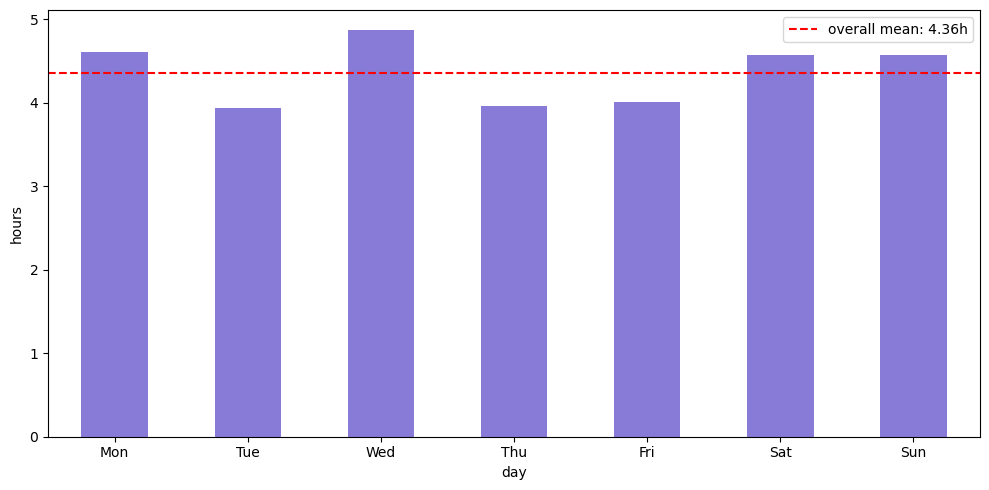

In [46]:

activity = login.groupby(['day', 'day_of_week', 'user_id', 'hour']).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0)

def calculate_peak_dist(row):
    peaks, _ = find_peaks(row.values, height=0)
    if len(peaks) > 1:
        return np.diff(peaks).mean()
    return np.nan

user_day_results = activity.apply(calculate_peak_dist, axis=1)
daily_date_averages = user_day_results.groupby(level=['day', 'day_of_week']).mean()
dow_averages = daily_date_averages.groupby(level='day_of_week').mean()

days_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_averages.index = dow_averages.index.map(days_map)
global_average = dow_averages.mean()

print("mean distance between peaks by day")
print(dow_averages)
print(f"\nGLOBAL mean of distance between peaks: {global_average:.2f} hours")


plt.figure(figsize=(10, 5))
dow_averages.plot(kind='bar', color='slateblue', alpha=0.8)
plt.ylabel('hours')
plt.xlabel('day')
plt.xticks(rotation=0)
plt.axhline(y=global_average, color='red', linestyle='--', label=f'overall mean: {global_average:.2f}h')
plt.legend()
plt.tight_layout()
plt.show()

Mean distance between peaks by day (starting after dawn)
day_of_week
Mon    4.431779
Tue    3.862426
Wed    4.786390
Thu    3.882189
Fri    3.907981
Sat    4.435474
Sun    4.309804
dtype: float64

GLOBAL mean: 4.23 hours


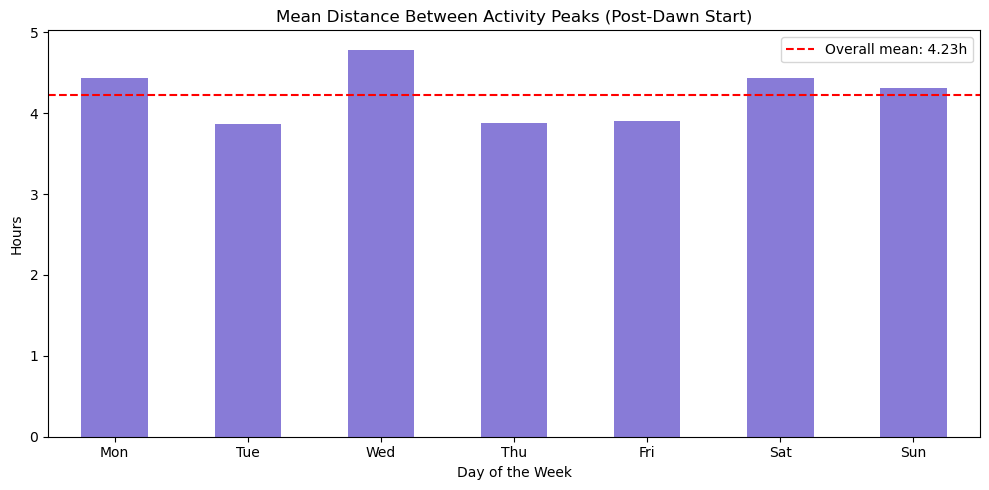

In [47]:
MORNING_THRESHOLD = 5

def calculate_morning_peak_dist(row):
    peaks, _ = find_peaks(row.values, height=0)
    morning_peaks = [p for p in peaks if p >= MORNING_THRESHOLD]
    if len(morning_peaks) > 1:
        return np.diff(morning_peaks).mean()
    return np.nan

activity = login.groupby(['day', 'day_of_week', 'user_id', 'hour']).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0)

user_day_results = activity.apply(calculate_morning_peak_dist, axis=1)
daily_date_averages = user_day_results.groupby(level=['day', 'day_of_week']).mean()
dow_averages = daily_date_averages.groupby(level='day_of_week').mean()

days_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_averages.index = dow_averages.index.map(days_map)
global_average = dow_averages.mean()

print("Mean distance between peaks by day (starting after dawn)")
print(dow_averages)
print(f"\nGLOBAL mean: {global_average:.2f} hours")

plt.figure(figsize=(10, 5))
dow_averages.plot(kind='bar', color='slateblue', alpha=0.8)
plt.ylabel('Hours')
plt.xlabel('Day of the Week')
plt.xticks(rotation=0)
plt.axhline(y=global_average, color='red', linestyle='--', label=f'Overall mean: {global_average:.2f}h')
plt.title('Mean Distance Between Activity Peaks (Post-Dawn Start)')
plt.legend()
plt.tight_layout()
plt.savefig('peak_distances.png')

Elimina sesgos de "Heavy Users": Si un usuario tiene 50 picos en un día y otro solo 2, el promedio simple daría mucha más importancia al primero. Al promediar primero por usuario, cada individuo aporta un solo dato a la estadística del día.

# power law

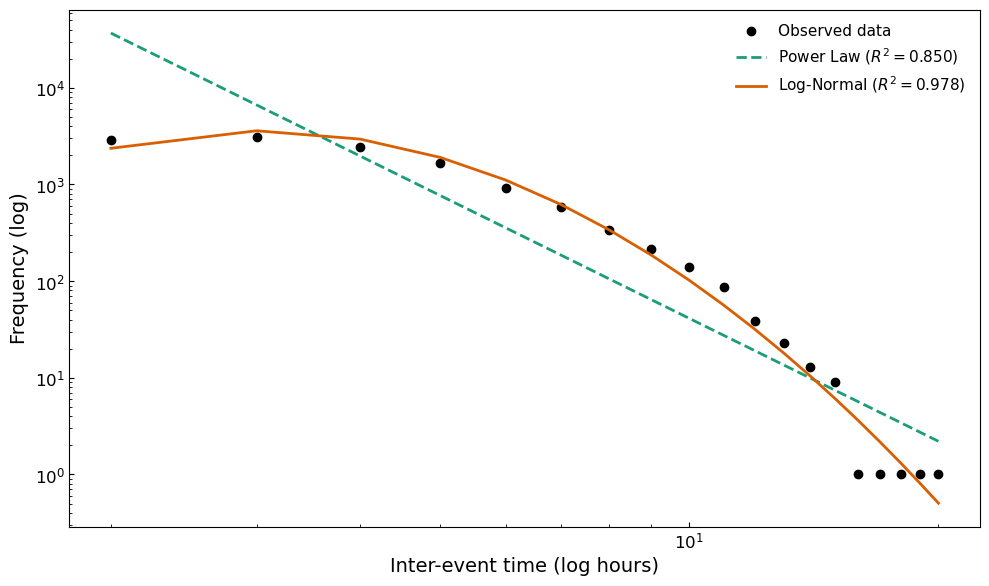

In [50]:
all_distances = []
for _, row in activity.iterrows():
    peaks, _ = find_peaks(row.values, height=0)
    if len(peaks) > 1:
        all_distances.extend(np.diff(peaks))

dist_counts = pd.Series(all_distances).value_counts().sort_index()
x_data = dist_counts.index.values.astype(float)
y_data = dist_counts.values.astype(float)

mask = x_data <= 24
x_data = x_data[mask]
y_data = y_data[mask]

log_x = np.log10(x_data)
log_y = np.log10(y_data)

p_pl = np.polyfit(log_x, log_y, 1)
y_fit_pl = 10**np.polyval(p_pl, log_x)
r2_pl = r2_score(log_y, np.polyval(p_pl, log_x))

p_ln = np.polyfit(log_x, log_y, 2)
y_fit_ln = 10**np.polyval(p_ln, log_x)
r2_ln = r2_score(log_y, np.polyval(p_ln, log_x))

cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data,label='Observed data', color = 'black')
plt.plot(x_data, y_fit_pl, color=cmap(0), lw=2, linestyle='--', label=f'Power Law ($R^2={r2_pl:.3f}$)')
plt.plot(x_data, y_fit_ln, color=cmap(1), lw=2, label=f'Log-Normal ($R^2={r2_ln:.3f}$)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Inter-event time (log hours)', fontsize=14)
plt.ylabel('Frequency (log)', fontsize=14)
plt.grid(False)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.tick_params(axis='both', direction='in', which='major', labelsize=12)
plt.tick_params(axis='both', direction='in', which='minor', labelsize=12)
#plt.savefig('figs/eq_logintimes.png', dpi=300)
plt.show()

In [51]:
alpha = -p_pl[0]
intercept_pl = 10**p_pl[1]
A, B, C_ln = p_ln

print(f"--- PARÁMETROS POWER LAW ---")
print(f"Ecuación: y = {intercept_pl:.2f} * x^(-{alpha:.2f})")
print(f"Exponente Alpha: {alpha:.4f}")
print(f"R2: {r2_pl:.4f}")

print(f"\n--- PARÁMETROS LOG-NORMAL ---")
print(f"Coeficientes de la parábola (log-log): A={A:.4f}, B={B:.4f}, C={C_ln:.4f}")
print(f"R2: {r2_ln:.4f}")

# Decisión estadística
if r2_ln > r2_pl:
    print("\nConclusión: El modelo Log-Normal explica mejor los tiempos de espera.")
else:
    print("\nConclusión: El modelo Power Law explica mejor los tiempos de espera.")

--- PARÁMETROS POWER LAW ---
Ecuación: y = 687553.44 * x^(-4.22)
Exponente Alpha: 4.2231
R2: 0.8497

--- PARÁMETROS LOG-NORMAL ---
Coeficientes de la parábola (log-log): A=-5.7050, B=5.4683, C=2.2450
R2: 0.9782

Conclusión: El modelo Log-Normal explica mejor los tiempos de espera.


In [53]:
sigma = np.sqrt(np.log(10) / (-2 * A)) 
print(f"Sigma: {sigma:.4f}")

mu = (B+1)*sigma**2
print(f"Mu:{mu:.4f}")


Sigma: 0.4492
Mu:1.3053


# interevent time

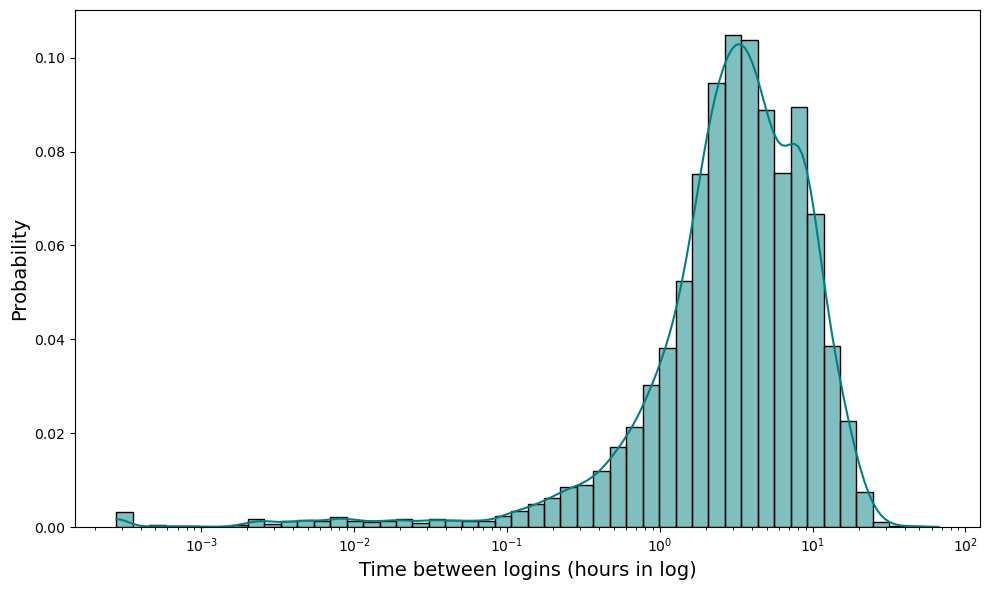

In [55]:
login['datetime'] = pd.to_timedelta(login['day'] - 1, unit='D') + pd.to_timedelta(login['time'])
login = login.sort_values(['user_id', 'datetime'])
login['delta_t'] = login.groupby('user_id')['datetime'].diff().dt.total_seconds() / 3600

deltas = login['delta_t'].dropna()
deltas = deltas[deltas > 0]

plt.figure(figsize=(10, 6))
sns.histplot(deltas, bins=50, kde=True, stat="probability", color='teal', log_scale=True)
plt.xlabel('Time between logins (hours in log)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()

Media: 4.71 horas
Mediana: 3.37 horas
En días: 0.20 días (media) vs 0.14 días (mediana)


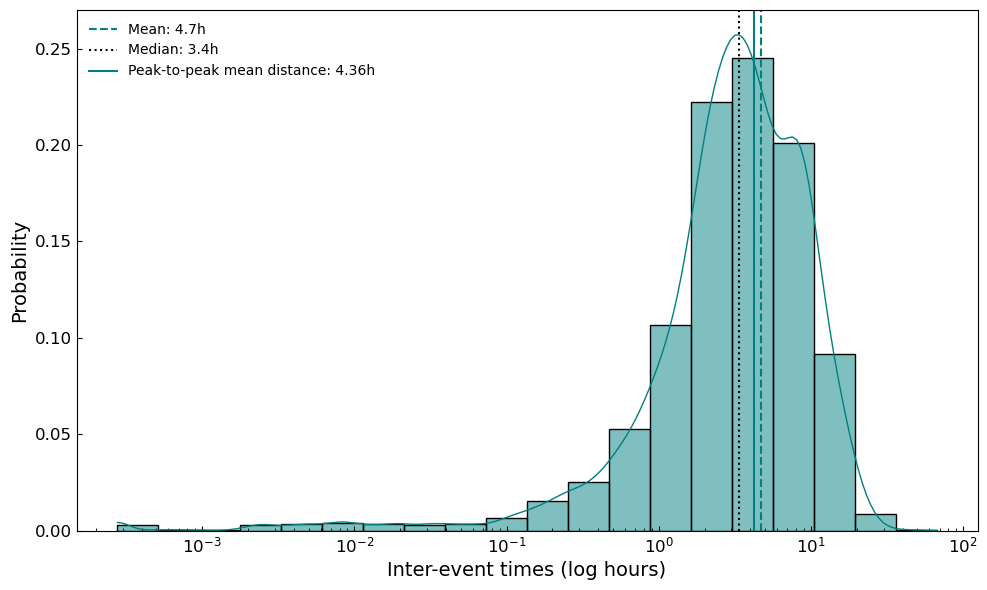

In [56]:
mean_delta = deltas.mean()
median_delta = deltas.median()

print(f"Media: {mean_delta:.2f} horas")
print(f"Mediana: {median_delta:.2f} horas")
print(f"En días: {mean_delta/24:.2f} días (media) vs {median_delta/24:.2f} días (mediana)")

plt.figure(figsize=(10, 6))
sns.histplot(deltas, bins=20, kde=True,  stat='probability',log_scale=True, alpha=0.5, color='#008080', line_kws={'color': 'black', 'linewidth': 1})
plt.axvline(mean_delta, color='teal', linestyle='--', label=f'Mean: {mean_delta:.1f}h')
plt.axvline(median_delta, color='black', linestyle=':', label=f'Median: {median_delta:.1f}h')
plt.axvline(4.23, color='teal', linestyle='-', label=f'Peak-to-peak mean distance: 4.36h')
plt.xlabel('Inter-event times (log hours)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.tick_params(axis='both', direction='in', which='minor')
plt.tick_params(axis='both', direction='in', which='major', labelsize=12)
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig('figs/hours.png', bbox_inches='tight', dpi=300)
plt.show()

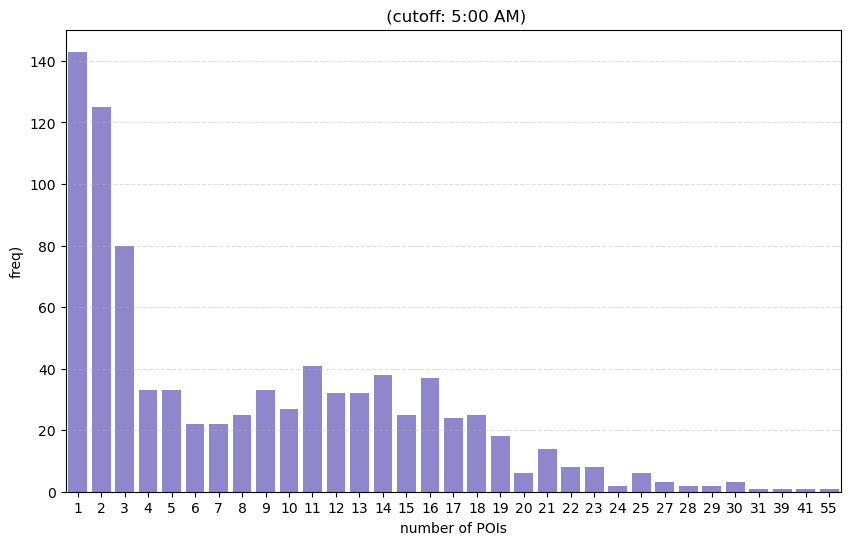

In [58]:
cutoff = 5
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_time'] = checkins['time'] - pd.Timedelta(hours=cutoff)
checkins['adj_day'] = checkins['adj_time'].dt.date

res = checkins.groupby(['user_id', 'adj_day'])['POI_id'].nunique().reset_index(name='n_pois')

plt.figure(figsize=(10, 6))
sns.countplot(data=res, x='n_pois', color='slateblue', alpha=0.8)
plt.xlabel('number of POIs')
plt.ylabel('freq)')
plt.title(f' (cutoff: {cutoff}:00 AM)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [59]:
res = checkins.groupby(['user_id', 'adj_day_4am'])['POI_id'].nunique().reset_index(name='n_pois')
umbral = 15
outliers = res[res['n_pois'] > umbral].sort_values(by='n_pois', ascending=False)

if not outliers.empty:
    top_user = outliers.iloc[0]['user_id']
    top_day_logico = outliers.iloc[0]['adj_day_4am']
    audit = checkins[(checkins['user_id'] == top_user) & 
                     (checkins['adj_day_4am'] == top_day_logico)].sort_values(by='time')
    audit['time_diff'] = audit['time'].diff().dt.total_seconds() / 60
    reales_unicos = audit['POI_id'].nunique()
    
    print(f"Usuario: {top_user}")
    print(f"Día Lógico (adj_day_4am): {top_day_logico}")
    print(f"POIs únicos detectados: {reales_unicos}")
    print(f"Total de check-ins en el día: {len(audit)}")
    print("-" * 50)
    print(audit[['time', 'POI_id', 'POI_category', 'time_diff']].head(20))
    
    if reales_unicos == outliers.iloc[0]['n_pois']:
        print(f"\n✅ VERIFICACIÓN CORRECTA: Los {reales_unicos} POIs coinciden con el conteo del reporte.")
    else:
        print(f"\n❌ ERROR DE CONTEO: Hay una discrepancia entre el reporte y la auditoría.")

else:
    print(f"No se encontraron usuarios con más de {umbral} POIs en un día lógico.")

KeyError: 'adj_day_4am'

In [ ]:
res = checkins.groupby(['user_id', 'day'])['POI_id'].nunique().reset_index(name='n_pois')
max_real = res['n_pois'].max()
print(f"El máximo real en el dataframe 'res' es: {max_real}")

top_row = res[res['n_pois'] == max_real].iloc[0]
u_id = top_row['user_id']
u_day = top_row['day']

print(f"Usuario: {u_id} | Día: {u_day}")
print(f"Según 'res', este usuario visitó {max_real} POIs únicos ese día.")
raw_data = checkins[(checkins['user_id'] == u_id) & (checkins['day'] == u_day)].sort_values(by='time')
print(f"\nPrimeros 10 check-ins de este usuario ese día:")
print(raw_data[['time', 'POI_id']].head(10))
unique_pois = raw_data['POI_id'].unique()
print(f"\nLista de POIs únicos contados: {len(unique_pois)}")

El máximo real en el dataframe 'res' es: 16

--- AUDITORÍA DEL MÁXIMO ---
Usuario: 99 | Día: 6
Según 'res', este usuario visitó 16 POIs únicos ese día.

Primeros 10 check-ins de este usuario ese día:
                     time                POI_id
9200  2026-06-16 00:16:59   6240187185276123346
9463  2026-06-16 07:57:20   6240187185276123346
9645  2026-06-16 09:17:32  14624418185447457320
9867  2026-06-16 10:47:41  11257892745349970971
9868  2026-06-16 10:47:49  15192729793732726753
9869  2026-06-16 10:47:56  11873406187507555652
9870  2026-06-16 10:48:05   6949076649787173565
9872  2026-06-16 10:48:14   7272720446072478133
9873  2026-06-16 10:48:21   6552456619915028642
10477 2026-06-16 17:24:34   8264171003901015939

Lista de POIs únicos contados: 16


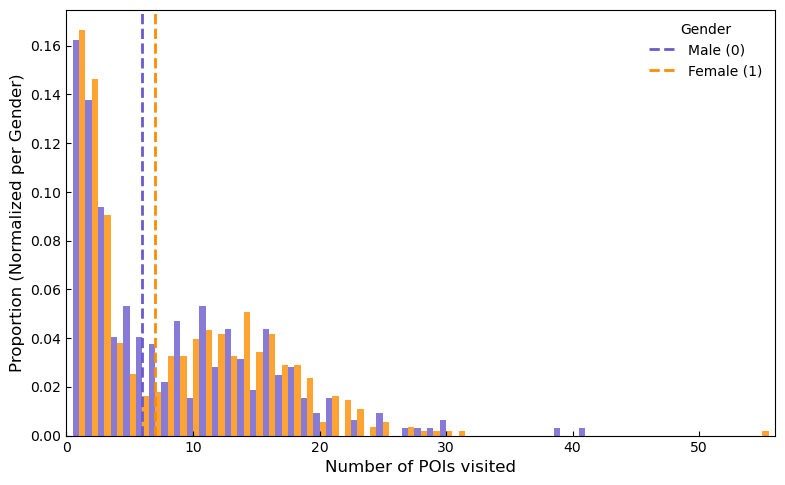

Estadísticas por Género:
        median       std
gender                  
0          6.0  7.191939
1          7.0  7.254227


In [61]:
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_day_4am'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date
res_final = checkins.groupby(['user_id', 'adj_day_4am', 'gender'])['POI_id'].nunique().reset_index(name='n_pois')
stats_gen = res_final.groupby('gender')['n_pois'].agg(['median', 'std'])

plt.figure(figsize=(8, 5))
palette_gender = {0: 'slateblue', 1: 'darkorange'}
ax = sns.histplot( data=res_final,  x='n_pois',  hue='gender', palette=palette_gender, alpha=0.8,  stat='proportion', common_norm=False,  multiple="dodge", discrete=True, edgecolor=None)
plt.xlabel('Number of POIs visited', fontsize=12)
plt.ylabel('Proportion (Normalized per Gender)', fontsize=12)

if 0 in stats_gen.index:
    plt.axvline(stats_gen.loc[0, 'median'], color='slateblue', linestyle='--', linewidth=2,label=f'Median Male: {stats_gen.loc[0, "median"]:.2f}')
if 1 in stats_gen.index:
    plt.axvline(stats_gen.loc[1, 'median'], color='darkorange', linestyle='--', linewidth=2,label=f'Median Female: {stats_gen.loc[1, "median"]:.2f}')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Male (0)', 'Female (1)'] + labels[2:], title='Gender', frameon=False)

# Configuración final de estilo
plt.grid(False)
plt.tight_layout()
plt.tick_params(axis='both', direction='in')
plt.xlim(0,56)
plt.savefig('distribucion_pois_genero_final.png', dpi=300)
plt.show()

print("Estadísticas por Género:")
print(stats_gen)

In [ ]:
def calculate_rg_metrics(df_user):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    if loc_counts.empty: return 0.0
    N = loc_counts['n_i'].sum()
    r_cm_lat = (loc_counts['latitude'] * loc_counts['n_i']).sum() / N
    r_cm_lon = (loc_counts['longitude'] * loc_counts['n_i']).sum() / N
    dx = (loc_counts['latitude'] - r_cm_lat) * 111
    dy = (loc_counts['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
    sq_dist = dx**2 + dy**2
    
    return np.sqrt((loc_counts['n_i'] * sq_dist).sum() / N)

results = checkins.groupby('user_id').apply(lambda d: pd.Series({'rg': calculate_rg_metrics(d), 'gender': d['gender'].iloc[0] })).reset_index()
stats_rg = results.groupby('gender')['rg'].agg(['mean', 'std'])

plt.figure(figsize=(10, 6))
palette_gender = {0: 'slateblue', 1: 'darkorange'}
sns.kdeplot(data=results, x='rg', hue='gender', palette=palette_gender, fill=True, alpha=0.4, linewidth=2, common_norm=False)
if 0 in stats_rg.index:
    plt.axvline(stats_rg.loc[0, 'mean'], color='slateblue', linestyle='--', linewidth=2,label=f'Mean Male: {stats_rg.loc[0, "mean"]:.2f} km')
if 1 in stats_rg.index:
    plt.axvline(stats_rg.loc[1, 'mean'], color='darkorange', linestyle='--', linewidth=2,label=f'Mean Female: {stats_rg.loc[1, "mean"]:.2f} km')
plt.xlabel('Radius of Gyration ($R_g$) [km]', fontsize=12)
plt.ylabel('Density', fontsize=12)
x_limit = results['rg'].quantile(0.99)
plt.xlim(0, x_limit)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', direction='in')
plt.grid(False)
plt.tight_layout()
plt.savefig('rg_genero_consistente.png', dpi=300)
plt.show()

print("rg by gender:")
print(stats_rg)

In [62]:
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_time'] = checkins['time'] - pd.Timedelta(hours=4)
checkins['adj_day'] = checkins['adj_time'].dt.date
res_final = checkins.groupby(['user_id', 'adj_day'])['POI_id'].nunique().reset_index(name='n_pois')
l_star_global = res_final['n_pois'].median()
deviation_global = res_final['n_pois'].std()
print(f"Registros originales en checkins: {len(checkins)}")
print(f"Total de trayectorias generadas (incluyendo de 1 POI): {len(res_final)}")
print(f"Media resultante: {res_final['n_pois'].mean():.2f}")
print(f"Mediana resultante (l_star): {l_star_global:.2f}")
print(f"Desviación estándar (sigma): {deviation_global:.2f}")

Registros originales en checkins: 20397
Total de trayectorias generadas (incluyendo de 1 POI): 873
Media resultante: 8.42
Mediana resultante (l_star): 7.00
Desviación estándar (sigma): 7.23


In [ ]:
#res_final.to_csv('reporte_trayectorias_pois.csv', index=False)
#res_final.to_excel('reporte_trayectorias_pois.xlsx', index=False)

print(res_final.head(10))

Vista previa del reporte:
   user_id adj_day_4am  n_pois
0        1  2026-04-08       1
1        1  2026-04-09      16
2        2  2026-04-08       2
3        2  2026-04-09       8
4        3  2026-04-08       2
5        3  2026-04-09       7
6        4  2026-04-08       3
7        4  2026-04-09      13
8        5  2026-04-08       1
9        5  2026-04-09      12


Total usuarios únicos: 467
Promedio de días activos por usuario: 1.87 días
Máximo de días que un usuario estuvo activo: 2
Mínimo de días que un usuario estuvo activo: 1


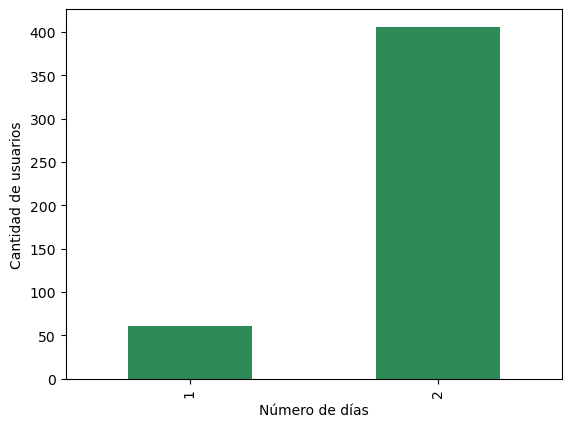

In [63]:
dias_por_usuario = res_final.groupby('user_id').size()
print(f"Total usuarios únicos: {len(dias_por_usuario)}")
print(f"Promedio de días activos por usuario: {dias_por_usuario.mean():.2f} días")
print(f"Máximo de días que un usuario estuvo activo: {dias_por_usuario.max()}")
print(f"Mínimo de días que un usuario estuvo activo: {dias_por_usuario.min()}")
import matplotlib.pyplot as plt
dias_por_usuario.value_counts().sort_index().plot(kind='bar', color='seagreen')
plt.xlabel('Número de días')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [18]:
table = traj_peruser.value_counts().sort_index().reset_index(name='Users')
table.columns = ['Nº of trajectories', 'Users']
total_usuarios = table['Users'].sum()
table['% of Users'] = (table['Users'] / total_usuarios * 100).round(2)
print(table.to_string(index=False))

 Nº of trajectories  Users  % of Users
                  7      1        0.21
                  8      7        1.50
                  9      6        1.28
                 10     21        4.50
                 11    432       92.51


C:\Users\34633\AppData\Local\Temp\ipykernel_31188\4151454970.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = checkins.groupby('user_id').apply(lambda d: pd.Series({'rg': calculate_rg_metrics(d), 'gender': d['gender'].iloc[0]}))


Radio de Giro (Rg) medio por género:
gender
0.0    86.990826
1.0    55.698243
Name: rg, dtype: float64

Resumen detallado:
             mean         std  count
gender                              
0.0     86.990826  415.729739    172
1.0     55.698243  420.698488    295


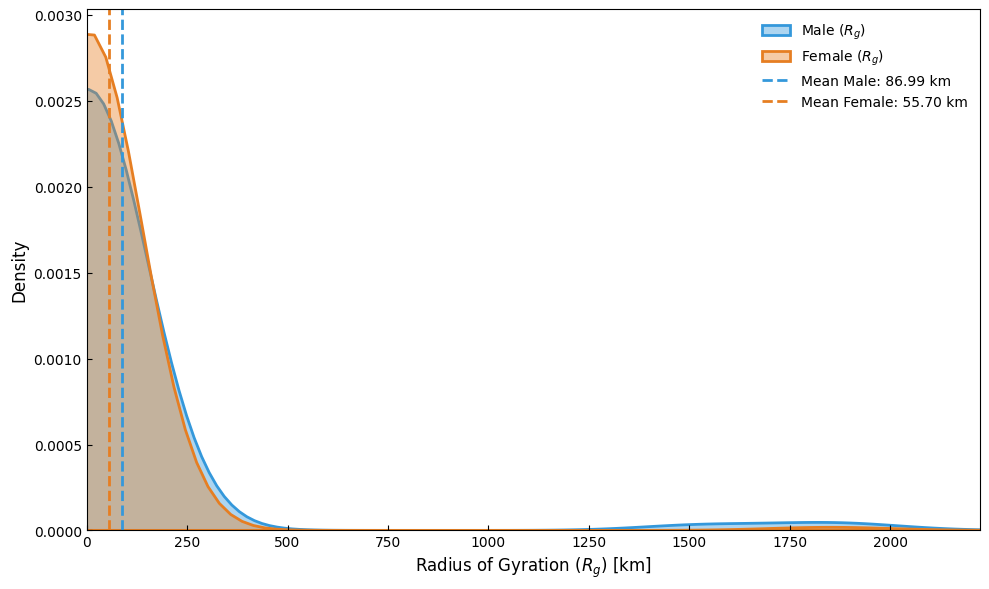

In [73]:
def calculate_rg_metrics(df_user, k_value=2):
    loc_counts = df_user.groupby(['latitude', 'longitude']).size().reset_index(name='n_i')
    loc_counts = loc_counts.sort_values(by='n_i', ascending=False).reset_index(drop=True)
    def get_rg(df_subset):
        if df_subset.empty: return 0.0
        N = df_subset['n_i'].sum()
        r_cm_lat = (df_subset['latitude'] * df_subset['n_i']).sum() / N
        r_cm_lon = (df_subset['longitude'] * df_subset['n_i']).sum() / N
        dx = (df_subset['latitude'] - r_cm_lat) * 111
        dy = (df_subset['longitude'] - r_cm_lon) * 111 * np.cos(np.radians(r_cm_lat))
        sq_dist = dx**2 + dy**2
        return np.sqrt((df_subset['n_i'] * sq_dist).sum() / N)
    return get_rg(loc_counts)
    
results = checkins.groupby('user_id').apply(lambda d: pd.Series({'rg': calculate_rg_metrics(d), 'gender': d['gender'].iloc[0]}))
rg_table = results.reset_index()
medias_genero = rg_table.groupby('gender')['rg'].mean()
print("Radio de Giro (Rg) medio por género:")
print(medias_genero)
print("\nResumen detallado:")
print(rg_table.groupby('gender')['rg'].agg(['mean', 'std', 'count']))


male_rg = rg_table[rg_table['gender'] == 0]['rg'].dropna()
female_rg = rg_table[rg_table['gender'] == 1]['rg'].dropna()
mean_male = male_rg.mean()
mean_female = female_rg.mean()

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e67e22'] 
sns.kdeplot(male_rg, fill=True, color=colors[0], label='Male ($R_g$)', alpha=0.4, linewidth=2)
sns.kdeplot(female_rg, fill=True, color=colors[1], label='Female ($R_g$)', alpha=0.4, linewidth=2)
plt.axvline(mean_male, color=colors[0], linestyle='--', linewidth=2, label=f'Mean Male: {mean_male:.2f} km')
plt.axvline(mean_female, color=colors[1], linestyle='--', linewidth=2, label=f'Mean Female: {mean_female:.2f} km')
plt.xlabel('Radius of Gyration ($R_g$) [km]', fontsize=12)
plt.ylabel('Density', fontsize=12)
x_limit = rg_table['rg'].quantile(0.99)
plt.xlim(0, x_limit)
plt.legend(frameon=False, fontsize=10)
plt.tick_params(axis='both', direction='in', labelsize=10)
plt.grid(False)
plt.tight_layout()
plt.savefig('rg.png', bbox_inches='tight', dpi = 300)
plt.show()

In [82]:
checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)

filtro = (checkins['user_id'] == 8) & (checkins['logical_day'] == 5)
resultado = checkins.loc[filtro]

resultado_final = resultado.sort_values(by=['day', 'time'])[['day', 'time', 'POI_id', 'POI_category']]
print(resultado_final)

C:\Users\34633\AppData\Local\Temp\ipykernel_31188\3214118492.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour


      day      time                POI_id POI_category
7511    5  07:25:12   2187661556938708261     Cultural
7883    5  09:57:39   7851260396140490874       School
8201    5  12:15:54  14259473054975606407    Residence
8697    5  16:34:08   7851260396140490874       School
9097    6  00:03:31  14259473054975606407    Residence


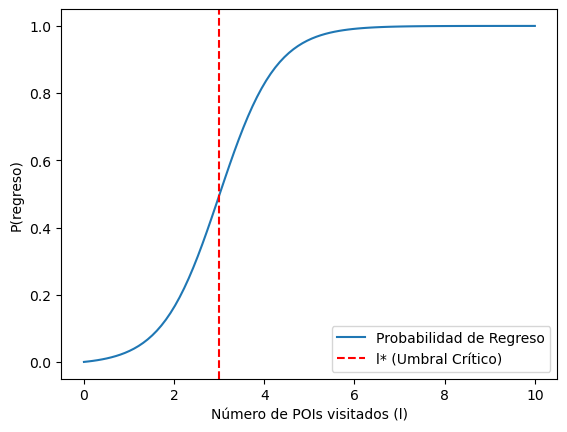

In [64]:
def p_regreso_inferida(A, l, l_star, sigma):
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    exponent = -(l - l_star) / kbt_a
    p = 1 / (1 + np.exp(exponent))
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    return (p - p_0) / (1 - p_0)

l_range = np.linspace(0, 10, 100)
probabilidades = p_regreso_inferida(0.9562946009839345, l_range, 3, 1.198)

plt.plot(l_range, probabilidades, label='Probabilidad de Regreso')
plt.axvline(x=3, color='r', linestyle='--', label='l* (Umbral Crítico)')
plt.xlabel('Número de POIs visitados (l)')
plt.ylabel('P(regreso)')
plt.legend()
plt.show()

In [ ]:
checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)
l_star = 3
sigma = 1.198
P_target = 0.95 
resultados = []

for (uid, l_day), group in checkins.groupby(['user_id', 'logical_day']):
    group = group.sort_values(by=['day', 'time'])
    l_final = len(group)
    if l_final > l_star:
        term_log = -np.log((1 / P_target) - 1)
        kbt_a_needed = (l_final - l_star) / term_log
        A_calculada = kbt_a_needed * np.pi / (sigma * np.sqrt(3))
    else:
        A_calculada = np.nan
    resultados.append({'user_id': uid,'logical_day': l_day,'n_pois': l_final,'A_inferida': A_calculada})
df_resultados = pd.DataFrame(resultados)
#df_resultados.to_csv('resultados_A_por_usuario_dia.csv', index=False)
print("Archivo 'resultados_A_por_usuario_dia.csv' generado con éxito.")

C:\Users\34633\AppData\Local\Temp\ipykernel_31188\1117977916.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour


Archivo 'resultados_A_por_usuario_dia.csv' generado con éxito.


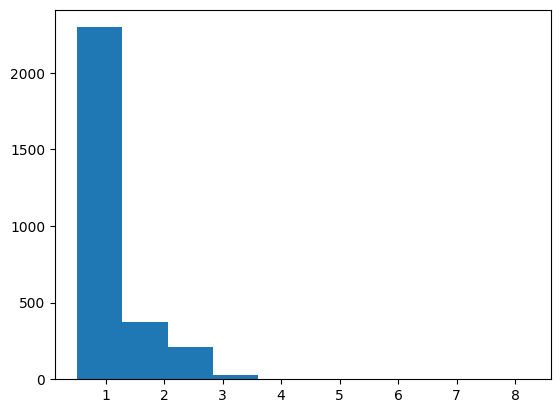

0.9562946009839345


In [96]:
plt.hist(Aresults, bins=10)
plt.show()

Aresults = df_resultados['A_inferida']
A = Aresults.mean()
print(A)

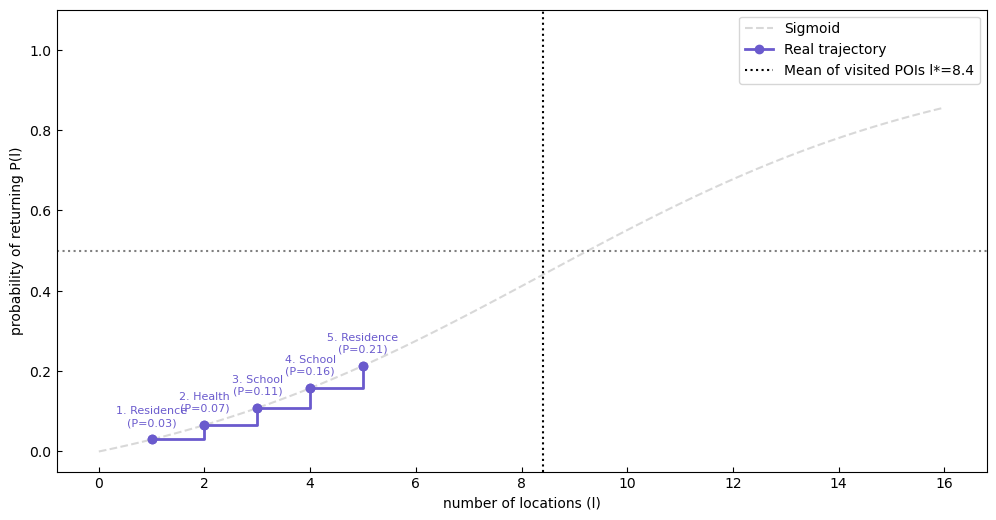

In [65]:
def p_teorica(l, A, l_star, sigma):
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    exponent = -(l - l_star) / kbt_a
    p = 1 / (1 + np.exp(exponent))
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    return (p - p_0) / (1 - p_0)

user_id = 1
dia_logico = 5
#l_star = 3
l_star = 8.4
sigma = 7.2
#sigma = 1.198
A_valor = 1.0 

checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)

trayectoria = checkins[(checkins['user_id'] == user_id) & (checkins['logical_day'] == dia_logico)].sort_values(by=['day', 'time'])
n_steps = len(trayectoria)
steps_reales = np.arange(1, n_steps + 1)
probs_reales = [p_teorica(l, A_valor, l_star, sigma) for l in steps_reales]

l_continuo = np.linspace(0, 16, 100)
p_continua = p_teorica(l_continuo, A_valor, l_star, sigma)

plt.figure(figsize=(12, 6))

plt.plot(l_continuo, p_continua, color='gray', alpha=0.3, label='Sigmoid', linestyle='--')
plt.step(steps_reales, probs_reales, where='post', color='slateblue', linewidth=2, label='Real trajectory', marker='o')
plt.scatter(steps_reales, probs_reales, marker='o', color='slateblue')

for i, (poi, p) in enumerate(zip(trayectoria['POI_category'], probs_reales)):
    plt.annotate(f"{i+1}. {poi}\n(P={p:.2f})", (steps_reales[i], p), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='slateblue')

plt.axvline(x=l_star, color='black', linestyle=':', label='Mean of visited POIs l*=8.4')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)

plt.ylim(-0.05, 1.1)
#plt.xlim(0, max(n_steps + 1, 6))
plt.xlabel('number of locations (l)')
plt.ylabel('probability of returning P(l)')
plt.legend()
plt.grid(False)
plt.tick_params(axis='both', direction='in')
plt.show()

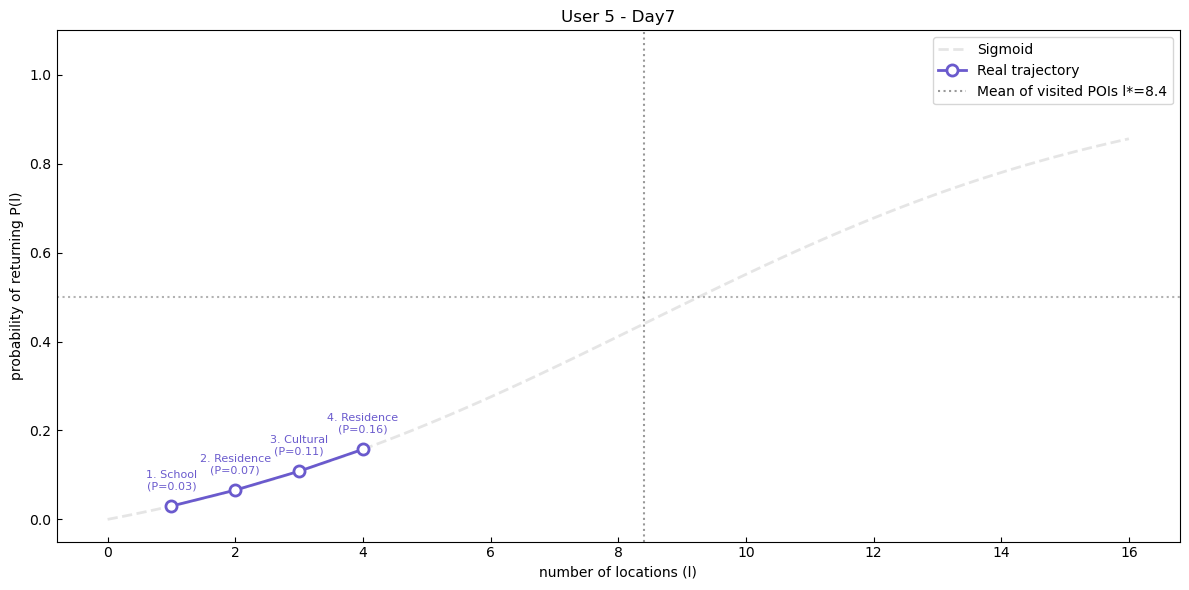

In [69]:
user_id = 5
dia_logico = 7
l_star = 8.4
#sigma = 1.198
sigma = 7.2
A_valor = 1.0 

checkins['hour_val'] = pd.to_datetime(checkins['time']).dt.hour
checkins['logical_day'] = checkins.apply(lambda x: x['day'] if x['hour_val'] >= 4 else x['day'] - 1, axis=1)
trayectoria = checkins[(checkins['user_id'] == user_id) & (checkins['logical_day'] == dia_logico)].sort_values(by=['day', 'time'])
n_steps = len(trayectoria)
steps_reales = np.arange(1, n_steps + 1)
probs_reales = [p_teorica(l, A_valor, l_star, sigma) for l in steps_reales]
l_continuo = np.linspace(0, 16, 100)
p_continua = p_teorica(l_continuo, A_valor, l_star, sigma)

plt.figure(figsize=(12, 6))
plt.plot(l_continuo, p_continua, color='gray', alpha=0.2, label='Sigmoid', linestyle='--', linewidth=2)
plt.plot(steps_reales, probs_reales, color='slateblue', marker='o', markersize=8, linewidth=2, label='Real trajectory', markerfacecolor='white', markeredgewidth=2)
for i, (poi, p) in enumerate(zip(trayectoria['POI_category'], probs_reales)):
    plt.annotate(f"{i+1}. {poi}\n(P={p:.2f})", (steps_reales[i], p), textcoords="offset points", xytext=(0,12), ha='center', fontsize=8, color='slateblue')

plt.axvline(x=l_star, color='black', linestyle=':', alpha=0.4, label=f'Mean of visited POIs l*={l_star}')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.3)
plt.ylim(-0.05, 1.1)
#plt.xlim(0, max(n_steps + 1, 6))
plt.xlabel('number of locations (l)')
plt.ylabel('probability of returning P(l)')
plt.title(f'User {user_id} - Day{dia_logico}')
plt.legend()
plt.grid(False)
plt.tick_params(direction='in', axis='both')
plt.tight_layout()
#plt.savefig('figs/sigmoid.png', bbox_inches='tight', dpi = 300)
plt.show()